# Predicción de Peso al Nacer — EPS PUJ

## Resumen

La EPS PUJ necesita anticipar **qué bebés nacerán con bajo peso (< 5.5 lb / 2 500 g)** para aprovisionar con tiempo los cuidados neonatales especializados, que son costosos y limitados. Este notebook documenta el flujo analítico completo (CRISP-DM) sobre la base de **4 255 156 nacimientos** del año 2022, desde la limpieza de datos hasta la comparación de **7 modelos predictivos** sobre la variable objetivo `weight_pounds` (regresión).

**Estructura del notebook**

1. **Carga de datos** — lectura del CSV con los nacimientos.
2. **Calidad de datos** — análisis de nulos y exclusión de variables con *leakage* o no disponibles al momento de predecir.
3. **Análisis exploratorio orientado al negocio** — distribución del peso, identificación de factores predictivos clave.
4. **Ingeniería de características** — indicadores de reporte, variables de riesgo clínico y manejo de outliers.
5. **Modelado predictivo** — 7 modelos (lineales, ensambles de árboles, SVM y red neuronal).
6. **Resultados comparativos** — métricas en test (MAPE y % dentro de ±10 %).

**Métrica de negocio.** Reportamos MAPE (error porcentual absoluto medio) y el % de predicciones dentro de ±10 % del peso real. Esta segunda métrica responde directamente a la pregunta operativa: *¿con qué frecuencia el modelo me permite estimar el peso del bebé con un error tolerable para decidir el nivel de cuidado?*


In [29]:
from pathlib import Path

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
RNG = 42
np.random.seed(RNG)

## 1. Carga de datos

Se carga el CSV con los 4 255 156 nacimientos reportados por la EPS para 2022 y se inspeccionan las primeras filas para confirmar el esquema.


In [30]:
DATA_PATH = Path("peso_bebes.csv")

df = pd.read_csv(DATA_PATH)

# Mapeo de códigos de raza según el diccionario de datos del caso
RACE_MAP = {
    1: "White",
    2: "Negro",
    3: "Indio americano",
    4: "Chino",
    5: "Japonés",
    6: "Hawaiian",
    7: "Filipino",
    9: "Desconocido/OTRO",
    18: "Indio Asiático",
    28: "Coreano",
    39: "Samoan",
    48: "Vietnamita",
    99: np.nan
}

def mapear_raza(s):
    """Convierte códigos a etiqueta, manda los no mapeados a 'Desconocido/OTRO'
    y preserva los NaN originales (para que el análisis de nulos siga siendo fiel)."""
    mapped = s.map(RACE_MAP)
    codigo_no_mapeado = s.notna() & mapped.isna()
    mapped.loc[codigo_no_mapeado] = "Desconocido/OTRO"
    return mapped.astype("category")

for col in ["child_race", "mother_race", "father_race"]:
    if col in df.columns:
        df[col] = mapear_raza(df[col])

print("Dimensiones:", df.shape)
df.head(10)

Dimensiones: (4255156, 31)


,source_year,year,month,day,wday,state,is_male,child_race,weight_pounds,plurality,apgar_1min,apgar_5min,mother_residence_state,mother_race,mother_age,gestation_weeks,lmp,mother_married,mother_birth_state,cigarette_use,cigarettes_per_day,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,ever_born,father_race,father_age,record_weight
0,2022,2022,4,NaN,5,NaN,False,NaN,6.4375,1,NaN,9.0000,NaN,NaN,34,38.0000,7282007,True,NaN,NaN,NaN,NaN,NaN,30.0000,NaN,NaN,NaN,8.0000,NaN,49,1
1,2022,2022,3,NaN,5,NaN,False,NaN,7.2620,1,NaN,9.0000,NaN,NaN,38,40.0000,6102007,True,NaN,NaN,NaN,NaN,NaN,99.0000,NaN,NaN,NaN,8.0000,NaN,45,1
2,2022,2022,12,NaN,2,NaN,True,NaN,6.0010,1,NaN,9.0000,NaN,NaN,30,36.0000,4202008,False,NaN,NaN,NaN,NaN,NaN,54.0000,NaN,NaN,NaN,8.0000,NaN,38,1
3,2022,2022,10,NaN,4,NaN,True,NaN,8.1262,1,NaN,9.0000,NaN,NaN,31,38.0000,2052008,False,NaN,NaN,NaN,NaN,NaN,30.0000,NaN,NaN,NaN,8.0000,NaN,39,1
4,2022,2022,11,NaN,4,NaN,False,NaN,7.3127,1,NaN,9.0000,NaN,NaN,39,39.0000,2082008,True,NaN,NaN,NaN,NaN,NaN,10.0000,NaN,NaN,NaN,8.0000,NaN,40,1
5,2022,2022,10,NaN,5,NaN,False,NaN,5.7430,1,NaN,9.0000,NaN,NaN,34,33.0000,9082008,False,NaN,NaN,NaN,NaN,NaN,38.0000,NaN,NaN,NaN,8.0000,NaN,40,1
6,2022,2022,7,NaN,4,NaN,True,NaN,9.4997,1,NaN,9.0000,NaN,NaN,41,40.0000,9252007,True,NaN,False,NaN,False,NaN,22.0000,NaN,NaN,NaN,8.0000,NaN,44,1
7,2022,2022,9,NaN,7,NaN,False,NaN,6.2501,1,NaN,9.0000,NaN,NaN,31,37.0000,12172007,True,NaN,NaN,NaN,NaN,NaN,20.0000,NaN,NaN,NaN,8.0000,NaN,37,1
8,2022,2022,5,NaN,3,NaN,True,NaN,6.8123,1,NaN,9.0000,NaN,NaN,28,36.0000,9122007,True,NaN,NaN,NaN,NaN,NaN,25.0000,NaN,NaN,NaN,8.0000,NaN,30,1
9,2022,2022,7,NaN,5,NaN,False,NaN,4.2505,2,NaN,9.0000,NaN,NaN,35,37.0000,10302007,True,NaN,NaN,NaN,NaN,NaN,50.0000,NaN,NaN,NaN,8.0000,NaN,35,1


In [31]:
df.dtypes

source_year                  int64
year                         int64
month                        int64
day                        float64
wday                         int64
state                      float64
is_male                       bool
child_race                category
weight_pounds              float64
plurality                    int64
apgar_1min                 float64
apgar_5min                 float64
mother_residence_state     float64
mother_race               category
mother_age                   int64
gestation_weeks            float64
lmp                          int64
mother_married                bool
mother_birth_state         float64
cigarette_use               object
cigarettes_per_day         float64
alcohol_use                 object
drinks_per_week            float64
weight_gain_pounds         float64
born_alive_alive           float64
born_alive_dead            float64
born_dead                  float64
ever_born                  float64
father_race         

## 2. Calidad de datos

Antes de modelar se realizan tres tareas críticas:

1. **Normalizar `lmp`** (fecha del último período menstrual) a formato fecha para detectar valores inválidos.
2. **Cuantificar nulos** por columna.
3. **Excluir variables** que no estarán disponibles al momento de la predicción o que generan *leakage* (p. ej. apgar, que se mide después del parto).


In [32]:
lmp_str = df['lmp'].astype(str).str.zfill(8)
lmp_parsed = pd.to_datetime(lmp_str, format='%m%d%Y', errors='coerce')

df['lmp'] = lmp_parsed
print(f"Valores de fecha inválidos en lmp convertidos a nulo: {df['lmp'].isna().sum():,}")

Valores de fecha inválidos en lmp convertidos a nulo: 432,845


### 2.1 Nulos por columna

El siguiente resumen identifica columnas con datos faltantes. Hay tres patrones distintos:

- **100 % nulos** (`day`, `state`, `child_race`, `apgar_1min`, etc.): la EPS no captura estos campos; deben excluirse.
- **~65-68 % nulos** (`cigarette_use`, `alcohol_use`, `mother_race`): faltante de datos — refleja diferencias de reporte por estado, no ausencia del fenómeno. Imputar a 'No fuma' inventaría señal.
- **< 3 % nulos** (`weight_gain_pounds`, `ever_born`, `gestation_weeks`, `weight_pounds`): faltantes manejables con imputación.


In [33]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(2)

null_summary = pd.DataFrame({
    "nulos": null_counts,
    "porcentaje_nulos": null_pct.round(2)
}).sort_values("porcentaje_nulos", ascending=False)

# Mostrar solo columnas que tienen al menos un nulo
null_summary_filtered = null_summary[null_summary["nulos"] > 0]
print(f"Columnas con valores nulos: {len(null_summary_filtered)} de {len(df.columns)}")
print(f"Total de registros: {len(df):,}\n")
display(null_summary_filtered)

Columnas con valores nulos: 21 de 31
Total de registros: 4,255,156



,nulos,porcentaje_nulos
day,4255156,100.0000
state,4255156,100.0000
child_race,4255156,100.0000
apgar_1min,4255156,100.0000
mother_residence_state,4255156,100.0000
drinks_per_week,4255156,100.0000
mother_birth_state,4255156,100.0000
born_alive_alive,4255156,100.0000
born_alive_dead,4255156,100.0000
born_dead,4255156,100.0000


### 2.2 Variables excluidas

Se excluyen las variables que:

- Se miden **después del nacimiento** (`apgar_1min`, `apgar_5min`) → causarían fuga de información.
- Son **constantes o no aportan** (`source_year`, `year`, `month`, `day`, `wday`, `state`).
- Son metadatos administrativos (`record_weight`).
- Tienen 100 % de nulos (`child_race`, `mother_residence_state`, `born_alive_*`, `born_dead`).
- Son redundantes con `gestation_weeks` (`lmp`).


In [34]:
DROP_LEAKAGE = [
    "apgar_1min",
    "apgar_5min",
    "source_year",
    "year",
    "month",
    "day",
    "wday",
    "state",
    "child_race",
    "mother_residence_state",
    "mother_birth_state",
    "born_alive_alive",
    "born_alive_dead",
    "born_dead",
    "lmp",
    "record_weight",
    "drinks_per_week"
]

drop_present = [c for c in DROP_LEAKAGE if c in df.columns]
df_base = df.drop(columns=drop_present, errors="ignore").copy()
print("Eliminadas:", drop_present)
print("Columnas restantes:", list(df_base.columns))

Eliminadas: ['apgar_1min', 'apgar_5min', 'source_year', 'year', 'month', 'day', 'wday', 'state', 'child_race', 'mother_residence_state', 'mother_birth_state', 'born_alive_alive', 'born_alive_dead', 'born_dead', 'lmp', 'record_weight', 'drinks_per_week']
Columnas restantes: ['is_male', 'weight_pounds', 'plurality', 'mother_race', 'mother_age', 'gestation_weeks', 'mother_married', 'cigarette_use', 'cigarettes_per_day', 'alcohol_use', 'weight_gain_pounds', 'ever_born', 'father_race', 'father_age']


In [35]:
df_base.dtypes

is_male                   bool
weight_pounds          float64
plurality                int64
mother_race           category
mother_age               int64
gestation_weeks        float64
mother_married            bool
cigarette_use           object
cigarettes_per_day     float64
alcohol_use             object
weight_gain_pounds     float64
ever_born              float64
father_race           category
father_age               int64
dtype: object

### 2.3 Variable objetivo y filas válidas

La variable objetivo es **`weight_pounds`**. Las filas sin peso registrado no son útiles ni para entrenar ni para evaluar, por lo que decidimos que se eliminan, además solo corresponden a ~0.1 % de los registros.


In [36]:
df_base = df_base.dropna(subset=["weight_pounds"])

## 3. Análisis exploratorio


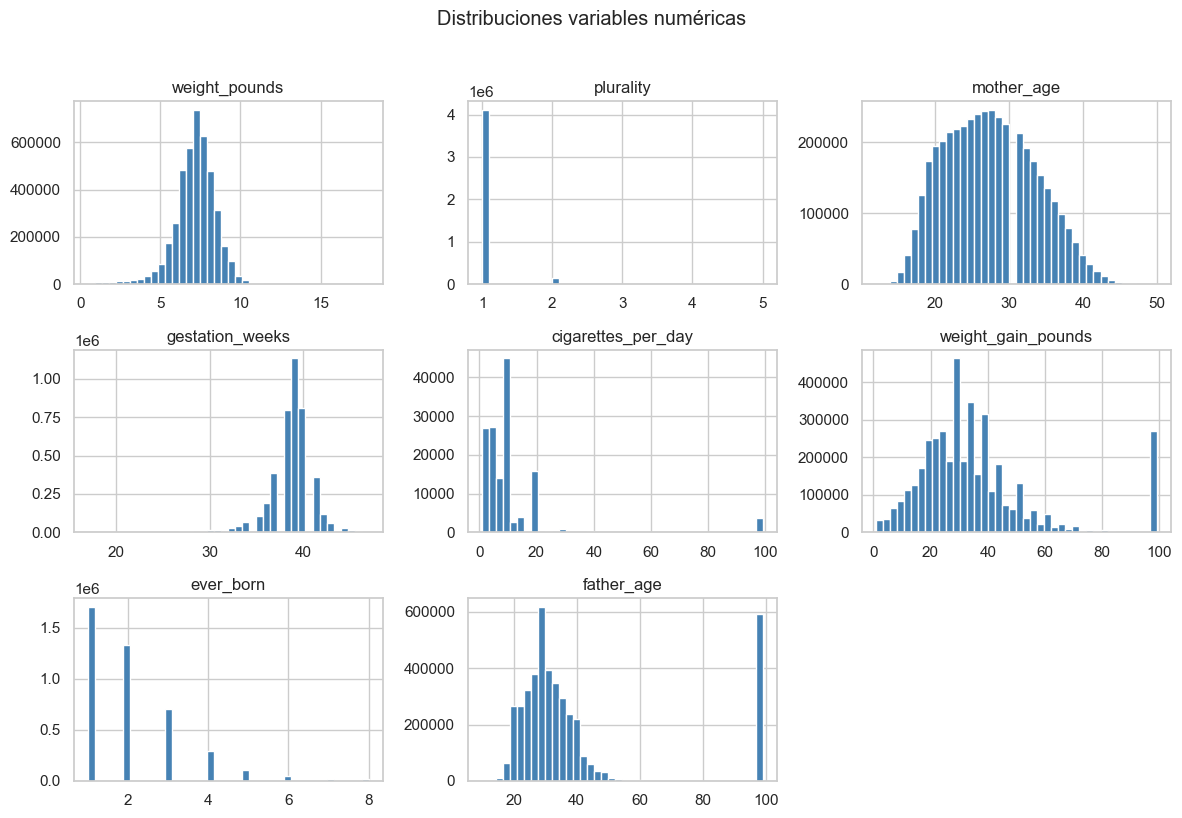

In [37]:
numeric_plot = df_base.select_dtypes(include=['number']).columns.tolist()
df_base[numeric_plot].hist(bins=40, figsize=(12, 8), color="steelblue", edgecolor="white")
plt.suptitle("Distribuciones variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

Con el histograma se observa que las variables `weight_gain_pounds` y `father_age` tienen valores atípicos registrados como 99, se va a proceder a poner estos datos dummie como nulos.

In [ ]:
df_base['weight_gain_pounds'] = df_base['weight_gain_pounds'].replace(99, np.nan)
df_base['father_age'] = df_base['father_age'].replace(99, np.nan)

### 3.1 Faltantes restantes tras la limpieza

Después de excluir las variables no usables, revisamos los faltantes que quedan en las features candidatas.

Observamos tres grupos de datos distintos, el primero `cigarettes_per_day` con 97% nulos, el segundo tabaco/alcohol/raza con ~65% nulos (`cigarette_use`, `alcohol_use`, `mother_race`, `father_race`), y un tercer grupo con menos del 10% (`weight_gain_pounds`, `ever_born`, `gestation_weeks`, `father_age`, `father_race`).

El hecho de que `cigarette_use` y `alcohol_use` tengan exactamente el mismo porcentaje (65.0091%) indica que se reportan juntas o no se reportan, así que estamos frente a un faltante de datos estructural.

En la sección 4.1 construimos indicadores `_reported` para que el modelo pueda distinguir "no consumo" de "no reportado", en lugar de imputar masivamente con la moda y meter sesgo.


In [39]:
feat_cols = [c for c in df_base.columns if c not in ("weight_pounds")]
miss = (df_base[feat_cols].isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
display(miss.to_frame("missing_%")) if len(miss) else print("Sin NAs en features listadas.")

,missing_%
cigarettes_per_day,96.6676
father_race,68.4441
mother_race,68.4441
cigarette_use,65.0091
alcohol_use,65.0091
father_age,8.4494
weight_gain_pounds,8.4494
ever_born,0.6058
gestation_weeks,0.1140


In [40]:
N_PLOT = 8_000_000
if len(df_base) > N_PLOT:
    plot_df = df_base.sample(n=N_PLOT, random_state=RNG)
else:
    plot_df = df_base

print(f"Tamaño de la muestra para gráficos: {len(plot_df):,} filas")


Tamaño de la muestra para gráficos: 4,250,791 filas


### 3.3 Distribución del peso al nacer
El peso de los bebes al nacer se comporta como una distribución unimodal centrada en ~7 libras con una cola izquierda larga visible hasta el umbral, y una cola derecha más corta. Con el histórico del año 2022 que se tiene se deduce que alrededor de 7.89% de los bebés cae por debajo de 5.5 libras.

La cola izquierda es una sub-población clínicamente diferenciada, probablemente prematuros y/o embarazos múltiples. Esto sugiere que un modelo de regresión sobre el peso continuo capturará la severidad mejor que una clasificación binaria, porque la EPS no solo necesita saber si el bebé está bajo el umbral, sino qué tan por debajo.

Sobre los 4.25M de nacimientos del 2022, el 7.89% equivale a unos **335 mil casos** que requieren cuidado neonatal especializado.

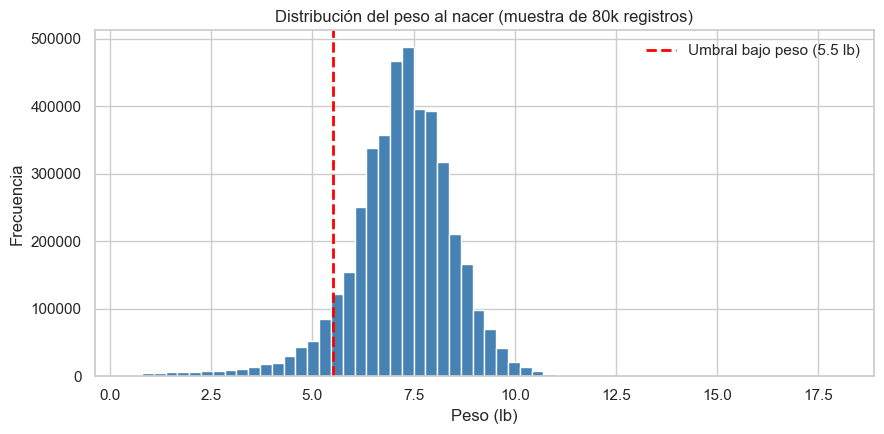

Proporción global de bebés con bajo peso (< 5.5 lb): 7.89%


In [41]:
# Distribución del peso al nacer con umbral clínico de bajo peso (5.5 lb)
UMBRAL_BAJO_PESO = 5.5

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(plot_df["weight_pounds"].dropna(), bins=60, color="steelblue", edgecolor="white")
ax.axvline(UMBRAL_BAJO_PESO, color="red", linestyle="--", linewidth=2,
           label=f"Umbral bajo peso ({UMBRAL_BAJO_PESO} lb)")
ax.set_title("Distribución del peso al nacer (muestra de 80k registros)")
ax.set_xlabel("Peso (lb)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

pct_bajo_peso = (df_base["weight_pounds"] < UMBRAL_BAJO_PESO).mean() * 100
print(f"Proporción global de bebés con bajo peso (< {UMBRAL_BAJO_PESO} lb): {pct_bajo_peso:.2f}%")


### 3.4 Correlación de predictores numéricos con el peso

Calculamos la correlación de Spearman, más robusta a no linealidades, entre cada variable numérica y `weight_pounds`.

Observamos que `gestation_weeks` domina con 0.39, más del doble del siguiente predictor. En el rango medio positivo (~0.17) aparecen empatados `father_race`, `father_age` y `weight_gain_pounds`. `mother_age` aporta señal moderada (0.09) y `ever_born` queda casi nula (0.04). Las negativas las lidera `plurality` (-0.25), seguida de `mother_race` (-0.15), mientras que `cigarettes_per_day` cae al rango débil (-0.05).

A partir de esto podemos plantear que la prematuridad sigue siendo el driver principal del bajo peso, lo cual coincide con la literatura clínica. Los embarazos múltiples son la segunda fuente de variabilidad porque comparten el espacio uterino. El bloque del padre (raza y edad) y la ganancia de peso de la madre aparecen con magnitud y signo positivo similares, lo que sugiere que reflejan en parte un perfil de embarazos a término en familias con mayor estabilidad. Que `mother_race` y `father_race` muestren signos opuestos confirma que la correlación de Spearman sobre un código nominal es solo orientativa: el efecto real va a emerger tras el One-Hot, donde cada categoría se trata por separado.

A partir de esto construimos variables como `riesgo_prematuro` (gestation_weeks < 37) para que los modelos lineales capturen el quiebre clínico y volveremos a ver la correlación de estas nuevas variables con el peso del bebé al nacer.


Correlación Spearman con weight_pounds:


,corr
gestation_weeks,0.3852
father_age,0.1699
weight_gain_pounds,0.1699
mother_age,0.0850
ever_born,0.0382
cigarettes_per_day,-0.0529
plurality,-0.2509


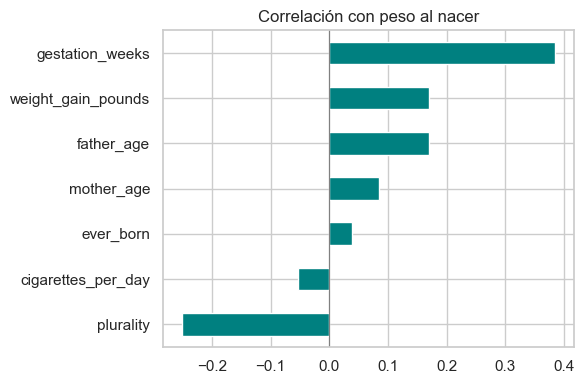

In [42]:
num_cols = df_base.select_dtypes(include=[np.number]).columns.tolist()
if "weight_pounds" in num_cols:
    num_cols.remove("weight_pounds")

corr_y = df_base[num_cols + ["weight_pounds"]].corr("spearman")["weight_pounds"].drop("weight_pounds").sort_values(ascending=False)
print("Correlación Spearman con weight_pounds:")
display(corr_y.to_frame("corr"))

plt.figure(figsize=(6, max(4, 0.35 * len(corr_y))))
corr_y.sort_values().plot(kind="barh", color="teal")
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Correlación con peso al nacer")
plt.tight_layout()
plt.show()

## 4. Ingeniería de características

Se construyen dos familias de variables:

- **Indicadores de reporte**: Con este buscamos convertir los faltantes en una señal explicita para el modelo de si hubo algún reporte de condiciones como el uso de cigarrillos o alcohol dentro del embarazo o la raza.

- **Variables de riesgo clínico/social**: Con estas buscamos codificar criterios usados en la literatura, como lo pueden ser la prematuridad, los embarazos múltiples, la edad de la madre, y la ganancia de peso.


### 4.1 Indicadores de reporte

| Nueva variable | Qué codifica |
|----------------|--------------|
| `cigarette_reported` | 1 si `cigarette_use` no es nulo; 0 si no hubo reporte. |
| `alcohol_reported` | Igual para alcohol. |
| `race_reported` | 1 si hay `mother_race` (proxy de captura). |
| `weight_gain_reported` | 1 si hay `weight_gain_pounds`. |

**Reglas** (cuando existan las columnas):

- Si `cigarette_use == False` y `cigarettes_per_day` es NA → **0** cigarrillos.

Con esto evitamos confundir el no consumo con los no reportados.


In [43]:
df_fe = df_base.copy()

if "cigarette_use" in df_fe.columns:
    df_fe["cigarette_reported"] = df_fe["cigarette_use"].notna().astype(np.int8)
if "alcohol_use" in df_fe.columns:
    df_fe["alcohol_reported"] = df_fe["alcohol_use"].notna().astype(np.int8)
if "mother_race" in df_fe.columns:
    df_fe["race_reported"] = df_fe["mother_race"].notna().astype(np.int8)
if "weight_gain_pounds" in df_fe.columns:
    df_fe["weight_gain_reported"] = df_fe["weight_gain_pounds"].notna().astype(np.int8)

if "cigarette_use" in df_fe.columns and "cigarettes_per_day" in df_fe.columns:
    mask = (df_fe["cigarette_use"] == False) & (df_fe["cigarettes_per_day"].isna())
    df_fe.loc[mask, "cigarettes_per_day"] = 0

report_cols = [c for c in ["cigarette_reported", "alcohol_reported", "race_reported", "weight_gain_reported"] if c in df_fe.columns]
if report_cols:
    display((df_fe[report_cols]*100).mean().round(2).to_frame("Porcentaje datos reportados"))

,Porcentaje datos reportados
cigarette_reported,34.9900
alcohol_reported,34.9900
race_reported,31.5600
weight_gain_reported,91.5500


### 4.2 Variables de riesgo clínico y social

Variables binarias interpretables que el modelo y el negocio pueden leer fácilmente:

| Variable | Definición | Por qué importa |
|----------|------------|-----------------|
| `riesgo_prematuro` | `gestation_weeks` < 37 | Prematuridad clínica. |
| `multiplo` | `plurality` > 1 | Indicador de embarazo múltiple |
| `madre_muy_joven` | `mother_age` < 20 | Indicador de maternidad temprana |
| `madre_mayor` | `mother_age` >= 35 | Indicador de maternidad geriatrica |
| `ganancia_baja_peso` | `weight_gain_pounds` < 15 lb | Indicador de poca ganancia de peso |
| `primigesta` | `ever_born` == 1 | Indicador de si la mamá es primeriza |
| `riesgo_social` | `mother_age` < 20 & `mother_married` = False | madre soltera + < 20 años |


In [44]:
if "gestation_weeks" in df_fe.columns:
    df_fe["riesgo_prematuro"] = (df_fe["gestation_weeks"] < 37).astype(np.int8)
if "plurality" in df_fe.columns:
    df_fe["multiplo"] = (df_fe["plurality"] > 1).astype(np.int8)
if "mother_age" in df_fe.columns:
    df_fe["madre_muy_joven"] = (df_fe["mother_age"] < 20).astype(np.int8)
    df_fe["madre_mayor"] = (df_fe["mother_age"] >= 35).astype(np.int8)
if "weight_gain_pounds" in df_fe.columns:
    df_fe["ganancia_baja_peso"] = (df_fe["weight_gain_pounds"] < 15).astype(np.int8)
    df_fe.loc[df_fe["weight_gain_pounds"].isna(), "ganancia_baja_peso"] = np.nan
if "ever_born" in df_fe.columns:
    df_fe["primigesta"] = (df_fe["ever_born"] == 1).astype(np.int8)
if "mother_married" in df_fe.columns and "mother_age" in df_fe.columns:
    mm = df_fe["mother_married"].astype("boolean")
    df_fe["riesgo_social"] = ((mm == False) & (df_fe["mother_age"] < 20)).astype(np.int8)

risk_cols = [c for c in ["riesgo_prematuro", "multiplo", "madre_muy_joven", "madre_mayor", "ganancia_baja_peso", "primigesta", "riesgo_social"] if c in df_fe.columns]
if risk_cols:
    display(df_fe[risk_cols].describe().T[["mean", "std"]])

,mean,std
riesgo_prematuro,0.1228,0.3282
multiplo,0.0341,0.1814
madre_muy_joven,0.1037,0.3048
madre_mayor,0.1419,0.3489
ganancia_baja_peso,0.0967,0.2955
primigesta,0.4012,0.4901
riesgo_social,0.0900,0.2862


### 4.3 Correlación de todas las variables con el peso

Para decidir qué variables dejar en el modelo, calculamos la correlación de Spearman de cada feature con `weight_pounds`. Incluimos tanto las variables originales del dataset como las que creamos en el feature enginieering, así podemos comparar en una misma vista qué aporta más y qué se podría descartar.

Esperamos ver en los primeros lugares (en valor absoluto) variables como `gestation_weeks` y `riesgo_prematuro`, y en los últimos las que aportan poca información y son candidatas a salir del modelo final.


Correlación:


,corr_con_peso
gestation_weeks,0.3852
riesgo_prematuro,-0.3643
plurality,-0.2509
multiplo,-0.2508
father_age,0.1699
weight_gain_pounds,0.1699
cigarettes_per_day,-0.1147
alcohol_use,-0.1140
cigarette_use,-0.1140
mother_married,0.1125


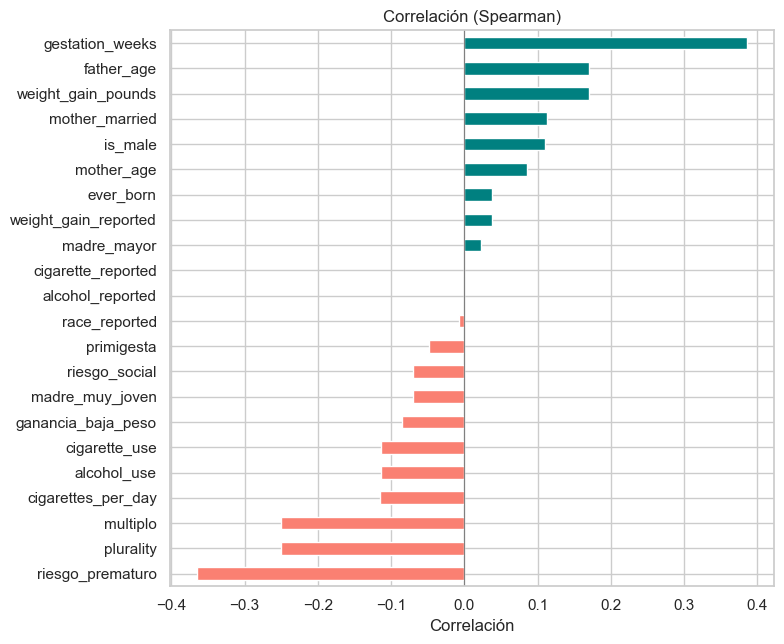

In [45]:
df_corr = df_fe.copy()

for col in df_corr.columns:
    s = df_corr[col]
    if s.dtype == bool or str(s.dtype) in ("boolean", "object"):
        mapped = s.map({True: 1.0, False: 0.0, "True": 1.0, "False": 0.0,
                        "TRUE": 1.0, "FALSE": 0.0})
        if mapped.notna().sum() == 0:
            mapped = pd.to_numeric(s, errors="coerce")
        df_corr[col] = mapped

num_all = df_corr.select_dtypes(include=[np.number]).columns.tolist()
num_all = [c for c in num_all if c != "weight_pounds"]

corr_all = (
    df_corr[num_all + ["weight_pounds"]]
    .corr("spearman")["weight_pounds"]
    .drop("weight_pounds")
)
corr_all = corr_all.reindex(corr_all.abs().sort_values(ascending=False).index)

print("Correlación:")
display(corr_all.to_frame("corr_con_peso"))

# Gráfico de barras horizontal coloreado por signo
colors = ["teal" if v >= 0 else "salmon" for v in corr_all.sort_values()]
plt.figure(figsize=(8, max(4, 0.3 * len(corr_all))))
corr_all.sort_values().plot(kind="barh", color=colors)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Correlación (Spearman)")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()


### 4.4 Outliers y valores dummie
Para limitar el efecto de los valores extremos hacemos dos cosas. Primero acotamos las variables clínicas a rangos biológicamente plausibles: `weight_pounds` entre 1 y 14 libras, y `gestation_weeks` entre 24 y 45 semanas. Segundo aplicamos un recorte por IQR en `mother_age` y `weight_gain_pounds` para quitar colas extremas que no aportan al modelo. Los valores centinela tipo 99 o 9999 ya quedaron limpios al parsear `lmp` y al imponer los rangos biológicos.


In [46]:
def clip_bio(df, col_weight="weight_pounds", col_gest="gestation_weeks"):
    out = df.copy()
    if col_weight in out.columns:
        out = out[(out[col_weight] >= 1) & (out[col_weight] <= 14)]
    if col_gest in out.columns:
        out = out[(out[col_gest] >= 24) & (out[col_gest] <= 45)]
    return out


def drop_iqr(df, col, k=1.5):
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return df[(df[col].isna()) | ((df[col] >= lo) & (df[col] <= hi))]


df_fe = clip_bio(df_fe)
df_fe = drop_iqr(df_fe, "mother_age")
df_fe = drop_iqr(df_fe, "weight_gain_pounds")

### 4.5 Features finales para modelado

A partir del análisis de correlación de §4.3 nos quedamos con 12 features. La elección de cada una responde tanto a su señal estadística como a su sentido clínico o de negocio.

**Variables continuas que mantenemos:**

- `gestation_weeks` (corr 0.39): es la variable más predictiva y la que tiene sentido biológico más directo, ya que a más semanas de gestación el bebé tiene más tiempo para desarrollarse y ganar peso. No puede faltar en el modelo.
- `plurality` (corr -0.25): los embarazos múltiples reducen sistemáticamente el peso individual de cada bebé porque comparten el mismo espacio uterino. Aporta una segunda fuente de señal independiente de la gestación.
- `weight_gain_pounds` (corr 0.17): la ganancia de peso de la madre durante el embarazo es un proxy directo del aporte nutricional al feto, lo cual la convierte en una variable accionable y clínicamente relevante.
- `cigarettes_per_day` (corr -0.11): cuantifica el consumo de tabaco con más detalle que el booleano `cigarette_use`. La elegimos sobre la versión binaria porque tiene más información y correlación ligeramente mejor.
- `mother_age` (corr 0.09): la edad de la madre tiene una relación en U con el peso al nacer (las maternidades muy tempranas y geriátricas son de mayor riesgo). La dejamos como continua para que los modelos de árbol puedan capturar esa forma no lineal por sí solos.
- `father_age` (corr 0.17): aparece con la misma magnitud que la ganancia de peso de la madre y con signo positivo, posiblemente como proxy de estabilidad familiar y acceso a controles prenatales. La incluimos porque aporta una señal complementaria a las variables maternas.

**Variables booleanas que mantenemos:**

- `alcohol_use` (corr -0.11): es la única señal de consumo de alcohol que sobrevive porque `drinks_per_week` quedó con 100% de nulos. La conservamos pese a su alta tasa de faltantes porque cuando se reporta sí discrimina.
- `mother_married` (corr 0.11): es un proxy del entorno socioeconómico y de la red de apoyo durante el embarazo, y aparece con correlación estable, así que aporta una dimensión social que las otras variables no cubren.
- `is_male` (corr 0.11): el sexo del bebé tiene un efecto pequeño pero consistente sobre el peso al nacer, según esto los niños pesan en promedio un poco más que las niñas.

**Variables categóricas que mantenemos:**

- `mother_race` y `father_race`: capturan diferencias fisiológicas documentadas en el peso neonatal entre grupos étnicos que persisten incluso a igual edad gestacional.

**Variable derivada que mantenemos:**

- `riesgo_prematuro` (corr -0.36): aunque es función directa de `gestation_weeks`, la dejamos porque codifica el quiebre clínico de las 37 semanas y aporta no linealidad a los modelos lineales.

**Variables descartadas y por qué:**

- `cigarette_use`: redundante con `cigarettes_per_day`, que es más informativa.
- `cigarette_reported`, `alcohol_reported`, `race_reported`, `weight_gain_reported`: la hipótesis de §4.1 era que el no tener datos era una señal, pero las cuatro tienen correlación cercana a cero (< 0.04), así que en la práctica no aportan al modelo.
- `multiplo`, `ganancia_baja_peso`, `madre_muy_joven`, `madre_mayor`, `riesgo_social`: son funciones directas de variables continuas que ya mantenemos (`plurality`, `weight_gain_pounds`, `mother_age`, `mother_married`), por lo que añaden colinealidad sin información nueva.
- `primigesta` y `ever_born`: correlación marginal (< 0.05) y se solapan entre sí; la paridad no muestra suficiente señal por sí sola para justificar el costo de los nulos.

Con esto pasamos de 24 a 12 features. Filtramos `df_fe` a esa lista para que §5 entrene directamente sobre el subset elegido. El preprocesamiento (imputación con mediana y escalado en numéricas, One-Hot en categóricas e imputación en booleanos) se aplica dentro del pipeline, de modo que cada modelo lo ajusta solo sobre su partición de entrenamiento y evitamos fugas hacia test.

In [47]:
FINAL_FEATURES = [
    "gestation_weeks",
    "plurality",
    "weight_gain_pounds",
    "cigarettes_per_day",
    "mother_age",
    "father_age",
    "alcohol_use",
    "mother_married",
    "is_male",
    "mother_race",
    "father_race",
    "riesgo_prematuro",
]

cols_to_keep = [c for c in FINAL_FEATURES if c in df_fe.columns] + ["weight_pounds"]
df_fe = df_fe[cols_to_keep].copy()
df_fe[['father_race','mother_race']] = df_fe[['father_race','mother_race']].astype("category")

X_cols = [c for c in df_fe.columns if c != "weight_pounds"]
print(f"Features finales: {len(X_cols)}")
print(X_cols)


Features finales: 12
['gestation_weeks', 'plurality', 'weight_gain_pounds', 'cigarettes_per_day', 'mother_age', 'father_age', 'alcohol_use', 'mother_married', 'is_male', 'mother_race', 'father_race', 'riesgo_prematuro']


## 5. Modelado

La variable `weight_pounds` es continua. Un clasificador binario (bajo peso sí/no) solo respondería si el bebé entra o no en cuidado especializado, pero escogimos la regresión porque nos dice qué tan por debajo del umbral está el peso del bebé, lo cual permite calibrar la severidad del cuidado y agregar pronósticos para planeación de recursos. Además, la base está muy desbalanceada, apenas 8% de bajo peso, lo cual penaliza el desempeño de los clasificadores estándar, mientras que la regresión usa toda la masa de la distribución.

Reportamos dos métricas alineadas con el negocio:

- **MAPE** (error porcentual absoluto medio): mide el error relativo promedio. Es escala-invariante y fácil de comunicar a negocio ("el modelo se equivoca en promedio X% del peso real").

- **% dentro de ±10%**: mide la proporción de predicciones lo suficientemente precisas para tomar la decisión operativa. Responde directamente a la pregunta de la EPS: *¿con qué frecuencia el modelo me da un estimado lo suficientemente bueno para asignar el cuidado correcto?*

Descartamos R² porque sobre una variable con poca varianza relativa (la mayoría de bebés pesan entre 6 y 8 libras) su valor no es intuitivo para decisiones operativas.

Cubrimos cinco familias para tener un panorama amplio entre interpretabilidad y capacidad predictiva: dos lineales (Regresión Lineal y Elastic Net), tres ensambles de árboles (Random Forest, XGBoost y LightGBM), un SVM lineal y una red neuronal. Todos usan el mismo dataset construido y el mismo split train/val/test. **Evaluamos en train y test** para detectar overfitting.


In [48]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.base import clone
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

plt.style.use("seaborn-v0_8-whitegrid")

N_SAMPLE_REG = 400_000

In [49]:
from sklearn.model_selection import train_test_split as _tts


def get_X_y(df, mode):
    drop_y = {"weight_pounds"}
    X = df.drop(columns=[c for c in drop_y if c in df.columns], errors="ignore")
    y = df["weight_pounds"]
    return X, y


def train_val_test_split(
    X,
    y,
    test_size=0.15,
    val_size=0.15,
    stratify=None,
    random_state=42,
):
    from sklearn.model_selection import train_test_split as tts

    X_temp, X_test, y_temp, y_test = tts(
        X,
        y,
        test_size=test_size,
        stratify=stratify,
        random_state=random_state,
    )
    val_rel = val_size / (1.0 - test_size)
    strat2 = y_temp if stratify is not None else None
    X_train, X_val, y_train, y_val = tts(
        X_temp,
        y_temp,
        test_size=val_rel,
        stratify=strat2,
        random_state=random_state,
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def detect_feature_types(X):
    num_cols = []
    cat_cols = []
    for c in X.columns:
        s = X[c]
        dt = s.dtype
        if pd.api.types.is_bool_dtype(dt) or str(dt) == "boolean":
            cat_cols.append(c)
        elif pd.api.types.is_numeric_dtype(dt):
            num_cols.append(c)
        else:
            cat_cols.append(c)
    return num_cols, cat_cols


def regression_scores(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    # MAPE (Mean Absolute Percentage Error)
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    # % de predicciones dentro de ±10% del valor real
    pct_within_10 = float(np.mean(np.abs((y_pred - y_true) / np.where(y_true == 0, 1, y_true)) <= 0.10) * 100)
    return {
        "MAPE_%": round(mape, 2),
        "dentro_10%": round(pct_within_10, 2),
    }


_df = df_fe.copy()
if len(_df) > N_SAMPLE_REG:
    df_reg = _df.sample(n=N_SAMPLE_REG, random_state=RNG).reset_index(drop=True)
else:
    df_reg = _df.copy()

Xr, yr = get_X_y(df_reg, "regression")
num_r, cat_r = detect_feature_types(Xr)
print("Regresión — filas:", len(yr), "| num:", len(num_r), "cat:", len(cat_r))


Regresión — filas: 400000 | num: 7 cat: 5


In [50]:
def _one_hot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
            drop="if_binary",
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
            drop="if_binary",
        )


def make_prep_linear(num_cols, cat_cols):
    transformers = []
    if num_cols:
        transformers.append(
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                num_cols,
            )
        )
    if cat_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", _one_hot_encoder()),
                    ]
                ),
                cat_cols,
            )
        )
    return ColumnTransformer(transformers, remainder="drop")


def make_prep_tree(num_cols, cat_cols):
    transformers = []
    if num_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), num_cols))
    if cat_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", _one_hot_encoder()),
                    ]
                ),
                cat_cols,
            )
        )
    return ColumnTransformer(transformers, remainder="drop")


def get_feature_names_safe(pipe, X_cols):
    prep = pipe.named_steps.get("prep") or pipe.named_steps.get("columntransformer")
    if prep is None:
        return [f"f{i}" for i in range(1000)]
    try:
        return list(prep.get_feature_names_out())
    except Exception:
        return [f"f{i}" for i in range(100)]


def plot_top_importance(names, values, title, ax=None, top=20):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(4, top * 0.22)))
    order = np.argsort(np.abs(values))[-top:]
    ax.barh(np.array(names)[order], np.array(values)[order], color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importancia / |coef.|")
    return ax


results_reg = []


In [51]:
def evaluar_modelo_peso(modelo, X, y_true, umbral_bajo=5.5):
    """
    Evalúa un modelo de regresión, con análisis de cuadrantes, Recall, 
    y una franja de tolerancia (+/- MAPE) para riesgos mitigados y falsas alarmas marginales.
    """
    
    # 1. Generar predicciones y consolidar
    y_pred = modelo.predict(X)
    df_eval = pd.DataFrame({'Peso_Real': y_true, 'Prediccion': y_pred})
    
    # 2. Calcular métricas a nivel de instancia
    df_eval['Error_Absoluto'] = np.abs(df_eval['Peso_Real'] - df_eval['Prediccion'])
    df_eval['Error_Porcentual'] = df_eval['Error_Absoluto'] / df_eval['Peso_Real']
    df_eval['Acierto_10pct'] = df_eval['Error_Porcentual'] <= 0.10
    
    # 3. Definir rangos para la tabla
    cortes = [0, 3.5, 5.5, 7.5, 9.5, np.inf]
    etiquetas = ['< 3.5 lbs (Severo)', '3.5 - 5.5 lbs (Bajo)', '5.5 - 7.5 lbs (Normal)', '7.5 - 9.5 lbs (Alto)', '> 9.5 lbs (Macrosomía)']
    df_eval['Rango_Peso'] = pd.cut(df_eval['Peso_Real'], bins=cortes, labels=etiquetas)
    
    analisis = df_eval.groupby('Rango_Peso', observed=False).agg(
        Volumen_Muestras=('Peso_Real', 'count'),
        MAE_Promedio=('Error_Absoluto', 'mean'),
        MAPE_Promedio=('Error_Porcentual', lambda x: x.mean() * 100),
        Tasa_Acierto_10pct=('Acierto_10pct', lambda x: x.mean() * 100)
    ).reset_index()
    analisis['%_del_Dataset'] = (analisis['Volumen_Muestras'] / len(df_eval)) * 100
    
    total_obs = len(df_eval)
    mape_global_decimal = df_eval['Error_Porcentual'].mean()
    
    # Definir los límites de la Banda de Tolerancia
    umbral_superior = umbral_bajo * (1 + mape_global_decimal)
    umbral_inferior = umbral_bajo * (1 - mape_global_decimal)
    
    # Conteo de cuadrantes
    q1_count = len(df_eval[(df_eval['Peso_Real'] >= umbral_bajo) & (df_eval['Prediccion'] >= umbral_bajo)])
    q2_count = len(df_eval[(df_eval['Peso_Real'] < umbral_bajo) & (df_eval['Prediccion'] >= umbral_bajo)]) # Omitidos (FN)
    q3_count = len(df_eval[(df_eval['Peso_Real'] < umbral_bajo) & (df_eval['Prediccion'] < umbral_bajo)])  # Detectados (VP)
    q4_count = len(df_eval[(df_eval['Peso_Real'] >= umbral_bajo) & (df_eval['Prediccion'] < umbral_bajo)])   # Falsas Alarmas (FP)
    
    # 1. Riesgos Mitigados (Omitidos que cayeron en el +MAPE)
    mascara_q2 = (df_eval['Peso_Real'] < umbral_bajo) & (df_eval['Prediccion'] >= umbral_bajo)
    omitidos_en_alerta = len(df_eval[mascara_q2 & (df_eval['Prediccion'] <= umbral_superior)])
    pct_mitigados = (omitidos_en_alerta / q2_count * 100) if q2_count > 0 else 0

    # 2. Falsas Alarmas Marginales (Alarmas que cayeron en el -MAPE)
    mascara_q4 = (df_eval['Peso_Real'] >= umbral_bajo) & (df_eval['Prediccion'] < umbral_bajo)
    alarmas_en_margen = len(df_eval[mascara_q4 & (df_eval['Prediccion'] >= umbral_inferior)])
    pct_alarmas_margen = (alarmas_en_margen / q4_count * 100) if q4_count > 0 else 0

    casos_reales_bajo_peso = q2_count + q3_count
    recall_bajo_peso = (q3_count / casos_reales_bajo_peso) * 100 if casos_reales_bajo_peso > 0 else 0

    # 4. Imprimir reporte en consola
    formatters = {
        'Volumen_Muestras': lambda x: f"{x:,}", '%_del_Dataset': lambda x: f"{x:.1f}%",
        'MAE_Promedio': lambda x: f"{x:.2f} lbs", 'MAPE_Promedio': lambda x: f"{x:.2f}%",
        'Tasa_Acierto_10pct': lambda x: f"{x:.1f}%"
    }
    print("\n" + "="*50)
    print("REPORTE DE EVALUACIÓN CLÍNICA Y DE NEGOCIO")
    print("="*50)
    print(f"MAPE Global:           {mape_global_decimal * 100:.2f}%")
    print(f"Banda de Tolerancia:   {umbral_inferior:.2f} lbs a {umbral_superior:.2f} lbs")
    print("-" * 50)
    print(analisis.to_string(index=False, formatters=formatters))
    print("="*50 + "\n")
    
    fig, ax = plt.subplots(figsize=(15, 8.5)) 
    
    sns.scatterplot(
        data=df_eval, x='Peso_Real', y='Prediccion', 
        hue='Rango_Peso', alpha=0.5, palette='viridis', edgecolor=None, ax=ax
    )
    
    # Línea de predicción perfecta
    min_val, max_val = df_eval['Peso_Real'].min(), df_eval['Peso_Real'].max()
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1.5)
    
    # Cruz de Umbrales (Negras punteadas)
    ax.axvline(x=umbral_bajo, color='black', linestyle=':', linewidth=2)
    ax.axhline(y=umbral_bajo, color='black', linestyle=':', linewidth=2)
    
    # Líneas y sombra de la BANDA DE TOLERANCIA (+/- MAPE)
    ax.axhline(y=umbral_superior, color='darkorange', linestyle='--', linewidth=1.5)
    ax.axhline(y=umbral_inferior, color='darkorange', linestyle='--', linewidth=1.5)
    ax.axhspan(umbral_inferior, umbral_superior, color='gold', alpha=0.15, zorder=0)
    
    # Cajas de texto (Cuadrantes internos)
    transform = ax.transAxes
    ax.text(0.95, 0.95, f'Q1: Sano Correcto\n{q1_count:,} casos', transform=transform, 
             fontsize=10, verticalalignment='top', horizontalalignment='right', 
             bbox=dict(boxstyle="round,pad=0.4", fc="#d4edda", ec="gray", alpha=0.9))
             
    ax.text(0.05, 0.95, f'Q2: Omitidos (Riesgo)\n{q2_count:,} casos', transform=transform, 
             fontsize=10, verticalalignment='top', horizontalalignment='left', 
             bbox=dict(boxstyle="round,pad=0.4", fc="#f8d7da", ec="red", alpha=0.9))
             
    ax.text(0.05, 0.05, f'Q3: Detectados\n{q3_count:,} casos', transform=transform, 
             fontsize=10, verticalalignment='bottom', horizontalalignment='left', 
             bbox=dict(boxstyle="round,pad=0.4", fc="#cce5ff", ec="blue", alpha=0.9))
             
    ax.text(0.95, 0.05, f'Q4: Falsa Alarma\n{q4_count:,} casos', transform=transform, 
             fontsize=10, verticalalignment='bottom', horizontalalignment='right', 
             bbox=dict(boxstyle="round,pad=0.4", fc="#fff3cd", ec="orange", alpha=0.9))

    ax.legend(bbox_to_anchor=(1.02, 0.98), loc='upper left', title="Categorías")
    
    # Bloque 1: RECALL
    ax.text(1.02, 0.73, f'Recall: {recall_bajo_peso:.1f}%\n\n'
                        f'Detectados (VP): {q3_count:,}\n'
                        f'Omitidos (FN): {q2_count:,}\n'
                        f'Total Reales < 5.5: {casos_reales_bajo_peso:,}', 
             transform=transform, fontsize=11, color='white', fontweight='bold',
             verticalalignment='top', horizontalalignment='left', 
             bbox=dict(boxstyle="round,pad=0.6", fc="#343a40", ec="black", alpha=0.9))

    # Bloque 2: RIESGOS MITIGADOS (+MAPE)
    ax.text(1.02, 0.48, f'Riesgos Mitigados (+MAPE)\n'
                        f'Rango: 5.5 a {umbral_superior:.2f} lbs\n\n'
                        f'De los {q2_count:,} omitidos,\n'
                        f'{omitidos_en_alerta:,} ({pct_mitigados:.1f}%) cayeron\n'
                        f'en la zona de Standby.\n\n'
                        f'-> El equipo médico\n'
                        f'estaba preparado.', 
             transform=transform, fontsize=11, color='black',
             verticalalignment='top', horizontalalignment='left', 
             bbox=dict(boxstyle="round,pad=0.6", fc="#fff3cd", ec="darkorange", alpha=0.9))

    # Bloque 3: COSTO OPERACIONAL (-MAPE)
    ax.text(1.02, 0.17, f'Costo Marginal (-MAPE)\n'
                        f'Rango: {umbral_inferior:.2f} a 5.5 lbs\n\n'
                        f'De las {q4_count:,} falsas alarmas,\n'
                        f'{alarmas_en_margen:,} ({pct_alarmas_margen:.1f}%) ocurrieron\n'
                        f'dentro del margen de\n'
                        f'error natural del modelo.\n\n'
                        f'-> Gasto justificable.', 
             transform=transform, fontsize=11, color='black',
             verticalalignment='top', horizontalalignment='left', 
             bbox=dict(boxstyle="round,pad=0.6", fc="#e2e3e5", ec="gray", alpha=0.9))

    # Títulos y formato general
    ax.set_title('Impacto Clínico y Análisis de Tolerancia Operacional (+/- MAPE)', fontsize=14, pad=15)
    ax.set_xlabel('Peso Real al Nacer (Libras)', fontsize=12)
    ax.set_ylabel('Peso Predicho por el Modelo (Libras)', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Ajustar margen para que los tres bloques encajen perfectamente
    plt.subplots_adjust(right=0.70) 
    plt.show()
    
    return analisis

### 5.1 Split train / val / test

Dividimos los datos en train (70%), validación (15%) y test (15%) con `random_state` fijo para que los resultados sean reproducibles.


In [52]:
X_train_r, X_val_r, X_test_r, y_train_r, y_val_r, y_test_r = train_val_test_split(
    Xr, yr, test_size=0.15, val_size=0.15, stratify=None, random_state=RNG
)
prep_lin_r = make_prep_linear(num_r, cat_r)
prep_tree_r = make_prep_tree(num_r, cat_r)
print("Regresión — train/val/test:", len(y_train_r), len(y_val_r), len(y_test_r))


Regresión — train/val/test: 279999 60001 60000


### 5.2 Modelo 1 — Regresión lineal (OLS)

Usamos OLS como baseline. Los coeficientes, en escala estandarizada, nos dicen qué tanto mueve el peso predicho cada feature.


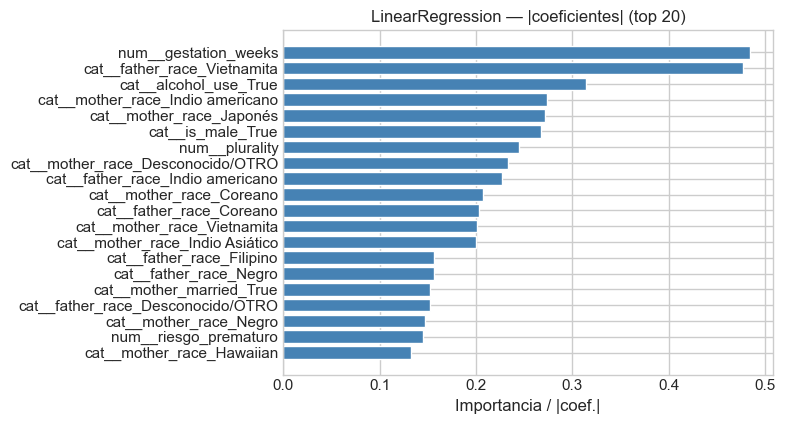

   MAPE_%  dentro_10%            modelo particion
0 12.0900     55.5800  LinearRegression     train
1 12.1300     55.2400  LinearRegression      test


In [53]:
name = "LinearRegression"
pipe = Pipeline([("prep", clone(prep_lin_r)), ("model", LinearRegression())])
pipe.fit(X_train_r, y_train_r)

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

coef = pipe.named_steps["model"].coef_
fn = get_feature_names_safe(pipe, Xr.columns)
imp = np.abs(coef)[: len(fn)]
plot_top_importance(fn[: len(imp)], imp, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()
print(pd.DataFrame(results_reg).query("modelo == @name"))



REPORTE DE EVALUACIÓN CLÍNICA Y DE NEGOCIO
MAPE Global:           12.13%
Banda de Tolerancia:   4.83 lbs a 6.17 lbs
--------------------------------------------------
            Rango_Peso Volumen_Muestras MAE_Promedio MAPE_Promedio Tasa_Acierto_10pct %_del_Dataset
    < 3.5 lbs (Severo)              836     2.01 lbs        90.60%               2.9%          1.4%
  3.5 - 5.5 lbs (Bajo)            3,789     1.33 lbs        28.10%              16.9%          6.3%
5.5 - 7.5 lbs (Normal)           30,029     0.64 lbs         9.93%              59.2%         50.0%
  7.5 - 9.5 lbs (Alto)           24,005     0.76 lbs         9.00%              61.2%         40.0%
> 9.5 lbs (Macrosomía)            1,341     2.37 lbs        23.48%               0.5%          2.2%



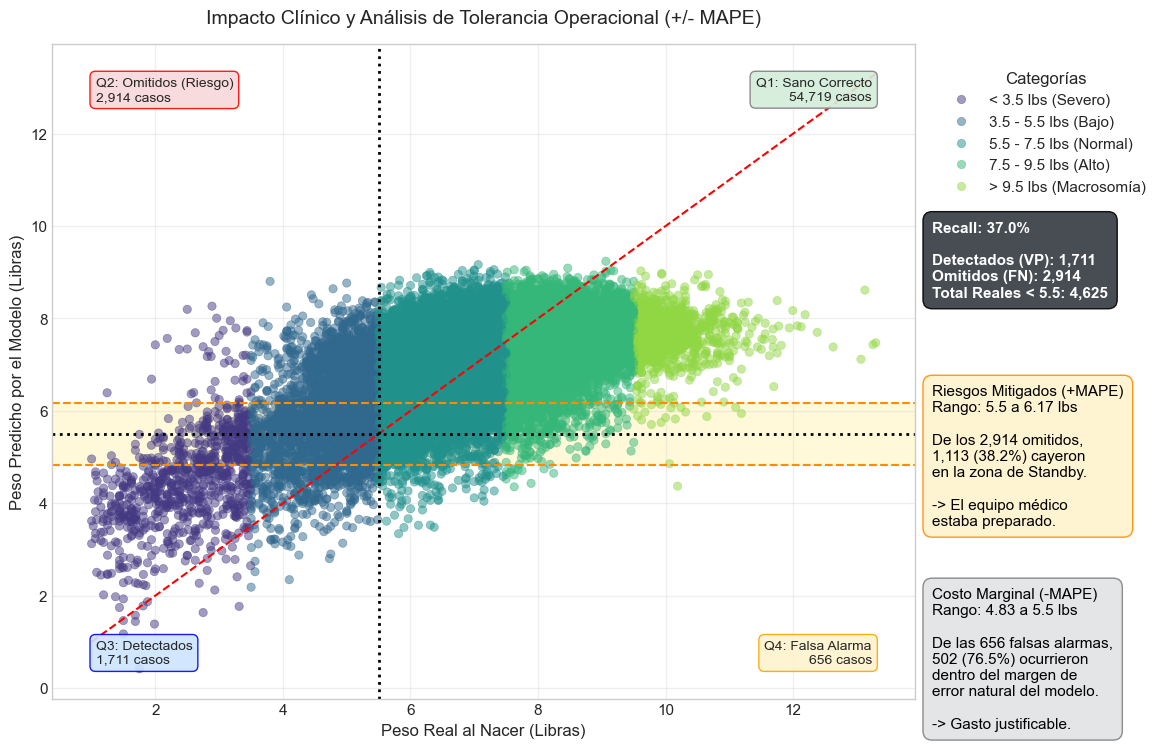

In [54]:
tabla_resultados_test = evaluar_modelo_peso(
    modelo = pipe,
    X = X_test_r,
    y_true = y_test_r
)

### 5.3 Modelo 2 — Regresión Lineal con Regularización

Elastic Net combina L1 (Lasso) y L2 (Ridge), lo que nos sirve para regularizar y hacer selección de variables cuando hay colinealidad. Se realiza una búsqueda exhaustiva de hiperparámetros con `GridSearchCV` optimizando directamente el **MAPE negativo** (neg_mean_absolute_percentage_error) para encontrar la mejor combinación de `alpha` y `l1_ratio`. Esto permite explorar desde Ridge puro (`l1_ratio=0`) hasta Lasso puro (`l1_ratio=1`), pasando por todas las mezclas intermedias.

**Espacio de búsqueda:**
- `alpha` ∈ {0.0001, 0.001, 0.01, 0.1, 0.5, 1.0}
- `l1_ratio` ∈ {0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0}
- `cv` = 5, `scoring` = neg_mean_absolute_percentage_error


In [55]:
umbral_bajo_peso = 5.5
multiplicador_peso = 5.0

weights = np.where(y_train_r < umbral_bajo_peso, multiplicador_peso, 1.0)

In [56]:
name = "Regresión con regularización"

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

pipe_base = Pipeline(
    [
        ("prep", clone(prep_lin_r)),
        ("model", ElasticNet(random_state=RNG, max_iter=10000)),
    ]
)

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 0.5],
    "model__l1_ratio": [0.0, 0.1, 0.5, 1.0],
}

grid_search = RandomizedSearchCV(
    pipe_base,
    param_distributions=param_grid,
    n_iter=16,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=RNG,
    return_train_score=True,
)

sample_idx = np.random.default_rng(RNG).choice(len(X_train_r), size=min(N_SAMPLE_REG, len(X_train_r)), replace=False)
X_sample = X_train_r.iloc[sample_idx]
y_sample = y_train_r.iloc[sample_idx]
w_sample = weights[sample_idx]

grid_search.fit(X_sample, y_sample, model__sample_weight=w_sample)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['gestation_weeks',
                                                                                'plurality',
                                                                                'weight_gain_pounds',
                                                                                'cigarettes_per_day',
                                                                                'mother_age',
                                                                                'father_age',
                                                                                'riesgo_prematuro']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleIm...
                                                                                                              sparse_output=False))]),
                                                                               ['alcohol_use',
                                                                                'mother_married',
                                                                                'is_male',
                                                                                'mother_race',
                                                                                'father_race'])])),
                                             ('model',
                                              ElasticNet(max_iter=10000,
                                                         random_state=42))]),
                   n_iter=16, n_jobs=-1,
                   param_distributions={'model__alpha': [0.001, 0.01, 0.1, 0.5],
                                        'model__l1_ratio': [0.0, 0.1, 0.5,
                                                            1.0]},
                   random_state=42, return_train_score=True,
                   scoring='neg_root_mean_squared_error', verbose=2)

In [57]:
# Mejor modelo y sus hiperparámetros
print("="*60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print(f"  alpha:    {grid_search.best_params_['model__alpha']}")
print(f"  l1_ratio: {grid_search.best_params_['model__l1_ratio']}")
print("="*60)

# Usar el mejor pipeline encontrado
pipe = grid_search.best_estimator_

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

MEJORES HIPERPARÁMETROS ENCONTRADOS:
  alpha:    0.001
  l1_ratio: 0.0


In [58]:
# --- Importancia de variables (|coeficientes|) ---
coef = np.abs(pipe.named_steps["model"].coef_)
fn = get_feature_names_safe(pipe, Xr.columns)
fn_arr = np.array(fn[: len(coef)])

# Ordenar por importancia descendente
sorted_idx = np.argsort(coef)[::-1]
top_n = 20

print(f"\n{'='*60}")
print(f"TOP {top_n} VARIABLES MÁS RELEVANTES PARA EL MODELO:")
print(f"{'='*60}")
for i, idx in enumerate(sorted_idx[:top_n], 1):
    print(f"  {i:2d}. {fn_arr[idx]:<35s} |coef| = {coef[idx]:.6f}")

# Variables con coeficiente cero (eliminadas por regularización L1)
n_zero = np.sum(coef == 0)
print(f"\nVariables eliminadas (coef=0): {n_zero} de {len(coef)}")
print(f"Variables seleccionadas:        {len(coef) - n_zero} de {len(coef)}")


TOP 20 VARIABLES MÁS RELEVANTES PARA EL MODELO:
   1. num__gestation_weeks                |coef| = 0.648556
   2. cat__alcohol_use_True               |coef| = 0.339095
   3. cat__is_male_True                   |coef| = 0.275667
   4. cat__mother_race_Indio americano    |coef| = 0.251299
   5. cat__mother_married_True            |coef| = 0.195646
   6. cat__mother_race_Desconocido/OTRO   |coef| = 0.193633
   7. num__riesgo_prematuro               |coef| = 0.183369
   8. num__plurality                      |coef| = 0.181003
   9. cat__father_race_Indio americano    |coef| = 0.164433
  10. cat__mother_race_Indio Asiático     |coef| = 0.145496
  11. cat__father_race_Filipino           |coef| = 0.129577
  12. cat__mother_race_Negro              |coef| = 0.118883
  13. cat__mother_race_White              |coef| = 0.112176
  14. cat__father_race_Vietnamita         |coef| = 0.107584
  15. cat__father_race_Indio Asiático     |coef| = 0.106806
  16. num__weight_gain_pounds             |coef| = 

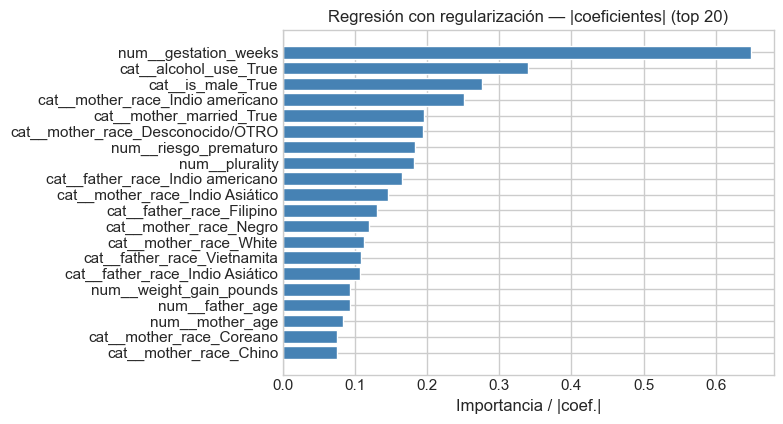


Resultados del modelo:
   MAPE_%  dentro_10%                        modelo particion
2 11.8000     53.5100  Regresión con regularización     train
3 11.8400     53.1700  Regresión con regularización      test


In [59]:
# Gráfico de importancia
plot_top_importance(fn[: len(coef)], coef, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()

print("\nResultados del modelo:")
print(pd.DataFrame(results_reg).query("modelo == @name"))

Las semanas de gestación dominan la predicción, seguidas por alcohol, sexo y plurality, con estas 5 variables se captura la mayor parte de la señal. El alcohol es el único factor modificable del top 5, lo que justifica programas de intervención temprana. Las diferencias por grupo étnico señalan poblaciones donde reforzar el acompañamiento prenatal.

In [60]:
import joblib

joblib.dump(grid_search.best_estimator_, "elasticnet_model.pkl")

print(f"Modelo guardado en: elasticnet_model.pkl")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")


Modelo guardado en: elasticnet_model.pkl
Mejores hiperparámetros: {'model__l1_ratio': 0.0, 'model__alpha': 0.001}



REPORTE DE EVALUACIÓN CLÍNICA Y DE NEGOCIO
MAPE Global:           11.84%
Banda de Tolerancia:   4.85 lbs a 6.15 lbs
--------------------------------------------------
            Rango_Peso Volumen_Muestras MAE_Promedio MAPE_Promedio Tasa_Acierto_10pct %_del_Dataset
    < 3.5 lbs (Severo)              836     1.17 lbs        51.53%              12.4%          1.4%
  3.5 - 5.5 lbs (Bajo)            3,789     1.04 lbs        21.79%              30.1%          6.3%
5.5 - 7.5 lbs (Normal)           30,029     0.60 lbs         9.25%              64.2%         50.0%
  7.5 - 9.5 lbs (Alto)           24,005     0.95 lbs        11.36%              47.3%         40.0%
> 9.5 lbs (Macrosomía)            1,341     2.55 lbs        25.32%               0.7%          2.2%



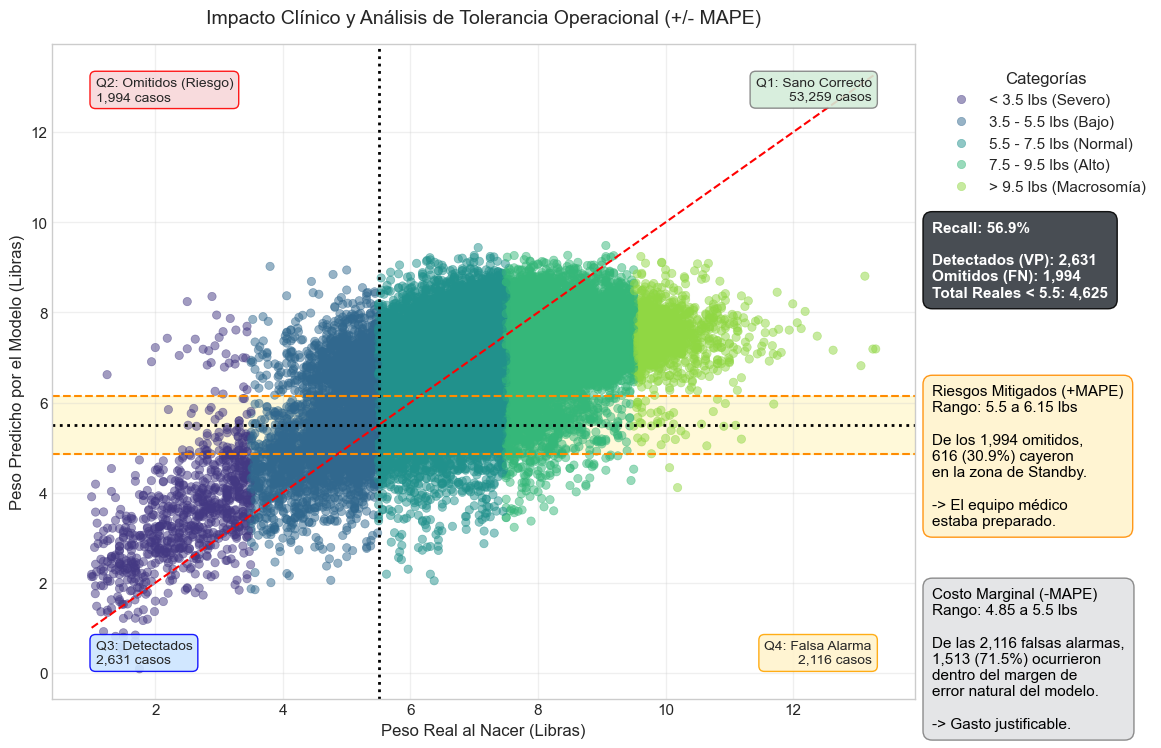

In [61]:
tabla_resultados_test = evaluar_modelo_peso(
    modelo = grid_search.best_estimator_,
    X = X_test_r,
    y_true = y_test_r
)

### 5.4 Modelo 3 — Random Forest

Ensamble de árboles entrenados con bootstrap. Captura no linealidades e interacciones sin ingeniería explícita, y su importancia de variables es fácil de comunicar. Se realiza una búsqueda exhaustiva de hiperparámetros con `RandomizedSearchCV` optimizando directamente el **MAPE negativo** para encontrar la mejor combinación de parámetros. Usamos búsqueda aleatoria en lugar de grid completo porque el espacio de hiperparámetros del Random Forest es muy grande y un grid exhaustivo sería computacionalmente prohibitivo.

**Espacio de búsqueda:**
- `n_estimators` ∈ {50, 100, 150, 200}
- `max_depth` ∈ {8, 12, 16, 20, None}
- `min_samples_split` ∈ {2, 5, 10, 20}
- `min_samples_leaf` ∈ {1, 10, 25, 50, 100}
- `max_features` ∈ {'sqrt', 'log2', 0.5, 1.0}
- `n_iter` = 30, `cv` = 3, `scoring` = neg_mean_absolute_percentage_error


In [62]:
name = "Random Forest"

pipe_base_rf = Pipeline(
    [
        ("prep", clone(prep_tree_r)),
        ("model", RandomForestRegressor(random_state=RNG, n_jobs=-1)),
    ]
)

In [63]:
param_dist_rf = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__max_depth": [8, 12, 16, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 10, 25, 50, 100],
    "model__max_features": ["sqrt", "log2", 0.5, 1.0],
}

In [64]:
rand_search_rf = RandomizedSearchCV(
    pipe_base_rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
    random_state=RNG,
    return_train_score=True,
)

rand_search_rf.fit(X_train_r, y_train_r, model__sample_weight=weights)



Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('num',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['gestation_weeks',
                                                                                'plurality',
                                                                                'weight_gain_pounds',
                                                                                'cigarettes_per_day',
                                                                                'mother_age',
                                                                                'father_age',
                                                                                'riesgo_prematuro']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop...
                                                                    random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [8, 12, 16, 20,
                                                             None],
                                        'model__max_features': ['sqrt', 'log2',
                                                                0.5, 1.0],
                                        'model__min_samples_leaf': [1, 10, 25,
                                                                    50, 100],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     20],
                                        'model__n_estimators': [50, 100, 150,
                                                                200]},
                   random_state=42, return_train_score=True,
                   scoring='neg_root_mean_squared_error', verbose=1)

In [65]:
print("=" * 60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")  
for param, value in rand_search_rf.best_params_.items():
    print(f"  {param.replace('model__', ''):<20s}: {value}")
print("=" * 60)

MEJORES HIPERPARÁMETROS ENCONTRADOS:
  n_estimators        : 50
  min_samples_split   : 10
  min_samples_leaf    : 1
  max_features        : sqrt
  max_depth           : 20


In [66]:
# Usar el mejor pipeline encontrado y evaluarlo en train/test
pipe = rand_search_rf.best_estimator_

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test", X_test_r, y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

print("Resultados del modelo:")
print(pd.DataFrame(results_reg).query("modelo == @name"))

Resultados del modelo:
   MAPE_%  dentro_10%         modelo particion
4 10.6700     57.3400  Random Forest     train
5 11.5200     54.9800  Random Forest      test


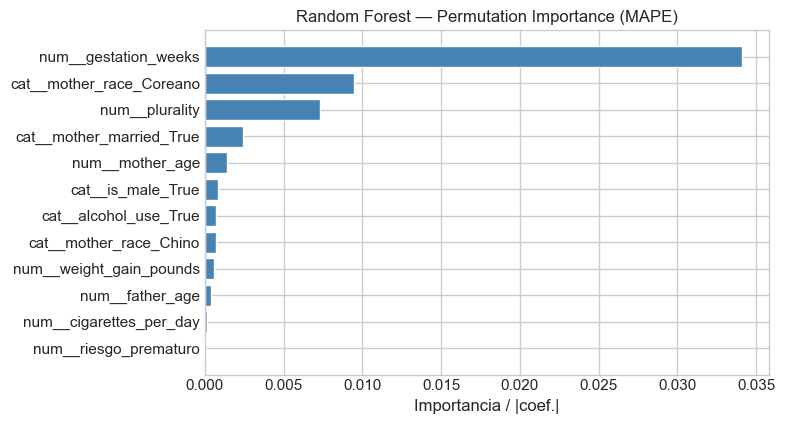

In [67]:
from sklearn.inspection import permutation_importance

resultado_importancia = permutation_importance(
    rand_search_rf.best_estimator_, 
    X_test_r, 
    y_test_r, 
    n_repeats=10, 
    random_state=RNG, 
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)

plot_top_importance(
    fn, 
    resultado_importancia.importances_mean, 
    f"{name} — Permutation Importance (MAPE)", 
    top=20
)
plt.tight_layout()
plt.show()

In [68]:
joblib.dump(rand_search_rf.best_estimator_, "random_forest_model.pkl")

print(f"Modelo guardado en: random_forest_model.pkl")
print(f"Mejores hiperparámetros: {rand_search_rf.best_params_}")

Modelo guardado en: random_forest_model.pkl
Mejores hiperparámetros: {'model__n_estimators': 50, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 20}



REPORTE DE EVALUACIÓN CLÍNICA Y DE NEGOCIO
MAPE Global:           11.52%
Banda de Tolerancia:   4.87 lbs a 6.13 lbs
--------------------------------------------------
            Rango_Peso Volumen_Muestras MAE_Promedio MAPE_Promedio Tasa_Acierto_10pct %_del_Dataset
    < 3.5 lbs (Severo)              836     1.17 lbs        51.31%              13.5%          1.4%
  3.5 - 5.5 lbs (Bajo)            3,789     1.05 lbs        21.95%              31.5%          6.3%
5.5 - 7.5 lbs (Normal)           30,029     0.62 lbs         9.50%              61.9%         50.0%
  7.5 - 9.5 lbs (Alto)           24,005     0.86 lbs        10.28%              54.5%         40.0%
> 9.5 lbs (Macrosomía)            1,341     2.50 lbs        24.80%               0.0%          2.2%



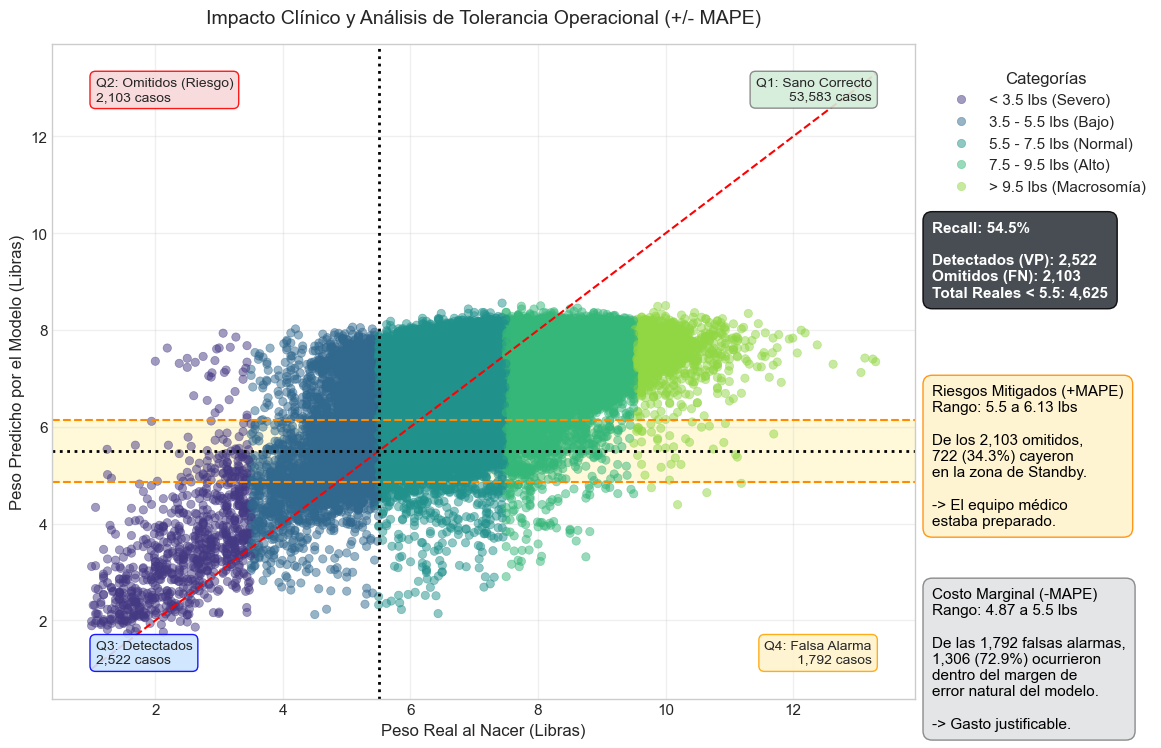

In [69]:
tabla_resultados_test = evaluar_modelo_peso(
    modelo = rand_search_rf.best_estimator_,
    X = X_test_r,
    y_true = y_test_r
)

### 5.5 Modelo 4 — XGBoost

Gradient boosting que entrena árboles secuencialmente corrigiendo los errores del modelo anterior. Suele dar el mejor trade-off entre precisión y tiempo en tabulares. **Hiperparámetros:** `n_estimators`=120, `max_depth`=8, `learning_rate`=0.08, `subsample`=0.8, `colsample_bytree`=0.8.


In [70]:
name = "XGBRegressor"

pipe = Pipeline([
    ("prep", clone(prep_tree_r)),
    ("model", XGBRegressor(
        tree_method="hist", 
        random_state=RNG,
        n_jobs=-1
    ))
])

param_grid = {
    'model__n_estimators': [100, 120, 150],
    'model__max_depth': [6, 8, 10],
    'model__learning_rate': [0.05, 0.08, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

grid_search_xg = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=15,
    random_state=RNG,
    verbose=1
)

grid_search_xg.fit(
    X_train_r, 
    y_train_r, 
    model__sample_weight=weights
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('num',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['gestation_weeks',
                                                                                'plurality',
                                                                                'weight_gain_pounds',
                                                                                'cigarettes_per_day',
                                                                                'mother_age',
                                                                                'father_age',
                                                                                'riesgo_prematuro']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop...
                                                           multi_strategy=None,
                                                           n_estimators=None,
                                                           n_jobs=-1,
                                                           num_parallel_tree=None, ...))]),
                   n_iter=40, n_jobs=15,
                   param_distributions={'model__colsample_bytree': [0.8, 1.0],
                                        'model__learning_rate': [0.05, 0.08,
                                                                 0.1],
                                        'model__max_depth': [6, 8, 10],
                                        'model__n_estimators': [100, 120, 150],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [71]:
print("=" * 60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")  
for param, value in grid_search_xg.best_params_.items():
    print(f"  {param.replace('model__', ''):<20s}: {value}")
print("=" * 60)

MEJORES HIPERPARÁMETROS ENCONTRADOS:
  subsample           : 0.8
  n_estimators        : 100
  max_depth           : 10
  learning_rate       : 0.05
  colsample_bytree    : 0.8


In [72]:
for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test", X_test_r, y_test_r),
]:
    pred = grid_search_xg.best_estimator_.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

print("Resultados del modelo:")
print(pd.DataFrame(results_reg).query("modelo == @name"))

Resultados del modelo:
   MAPE_%  dentro_10%        modelo particion
6 10.9500     55.9900  XGBRegressor     train
7 11.4000     54.6200  XGBRegressor      test


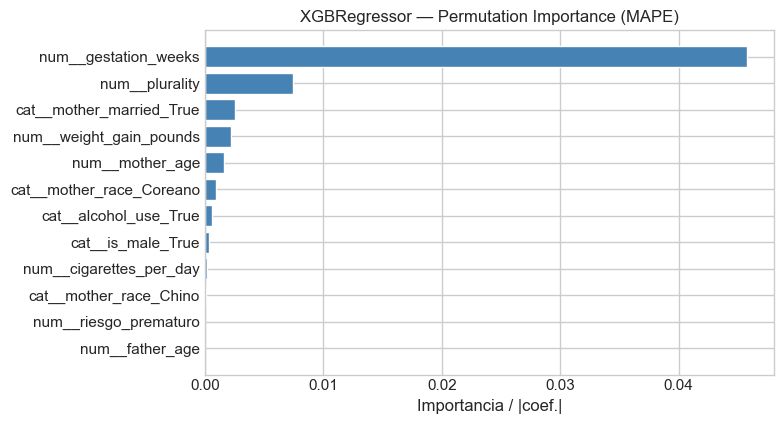

In [73]:
from sklearn.inspection import permutation_importance

resultado_importancia = permutation_importance(
    grid_search_xg.best_estimator_, 
    X_test_r, 
    y_test_r, 
    n_repeats=10, 
    random_state=RNG, 
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=-1
)

plot_top_importance(
    fn, 
    resultado_importancia.importances_mean, 
    f"{name} — Permutation Importance (MAPE)", 
    top=20
)
plt.tight_layout()
plt.show()

In [74]:
joblib.dump(grid_search_xg.best_estimator_, "xgboost_model.pkl")

print(f"Modelo guardado en: xgboost_model.pkl")
print(f"Mejores hiperparámetros: {grid_search_xg.best_params_}")

Modelo guardado en: xgboost_model.pkl
Mejores hiperparámetros: {'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}



REPORTE DE EVALUACIÓN CLÍNICA Y DE NEGOCIO
MAPE Global:           11.40%
Banda de Tolerancia:   4.87 lbs a 6.13 lbs
--------------------------------------------------
            Rango_Peso Volumen_Muestras MAE_Promedio MAPE_Promedio Tasa_Acierto_10pct %_del_Dataset
    < 3.5 lbs (Severo)              836     1.04 lbs        44.12%              17.0%          1.4%
  3.5 - 5.5 lbs (Bajo)            3,789     1.00 lbs        20.89%              33.3%          6.3%
5.5 - 7.5 lbs (Normal)           30,029     0.61 lbs         9.36%              62.5%         50.0%
  7.5 - 9.5 lbs (Alto)           24,005     0.89 lbs        10.57%              52.6%         40.0%
> 9.5 lbs (Macrosomía)            1,341     2.51 lbs        24.88%               0.0%          2.2%



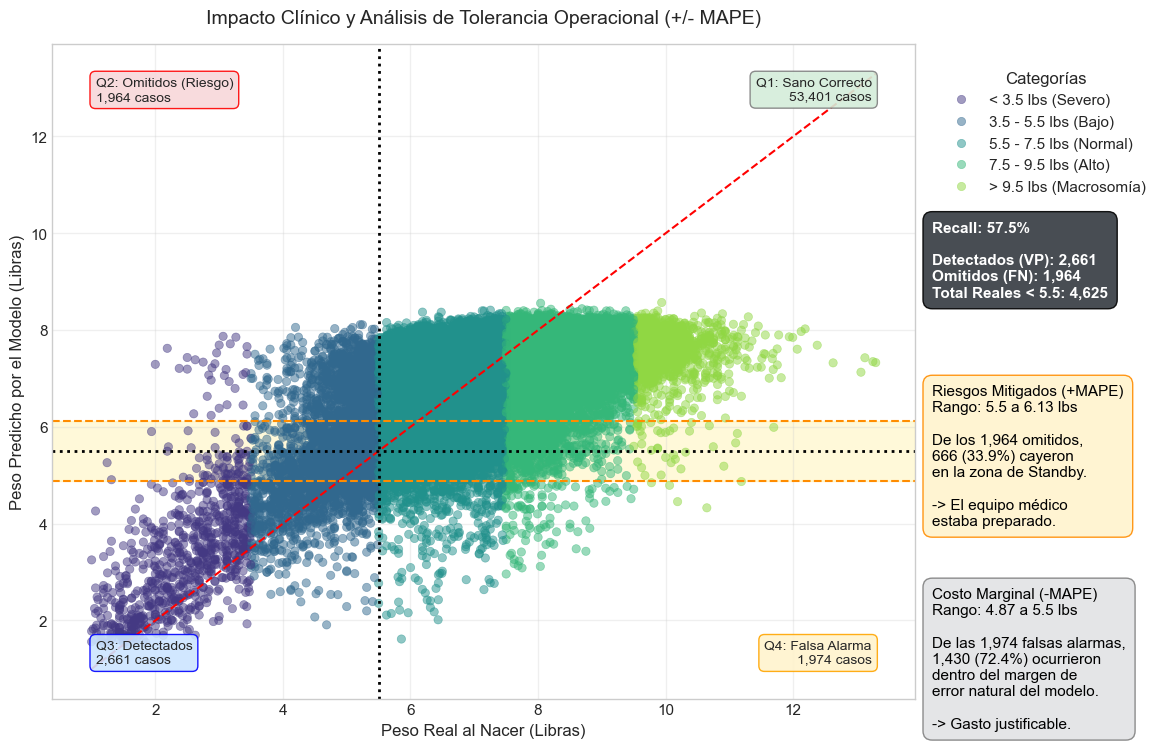

In [75]:
tabla_resultados_test = evaluar_modelo_peso(
    modelo = grid_search_xg.best_estimator_,
    X = X_test_r,
    y_true = y_test_r
)

### 5.6 Modelo 5 — CatBoost

Algoritmo de gradient boosting que codifica de forma nativa las variables categóricas mediante *ordered target statistics*, eliminando la necesidad de One-Hot Encoding y reduciendo el sobreajuste por *target leakage*. Utiliza árboles simétricos (*oblivious trees*) y la técnica de *ordered boosting* para mitigar el sesgo en las estimaciones de gradiente, lo que lo hace especialmente eficiente en GPU. Se realiza una búsqueda aleatoria de hiperparámetros con `RandomizedSearchCV` optimizando el **RMSE negativo**; el entrenamiento aprovecha GPU automáticamente si `torch.cuda.is_available()` es `True`.

**Espacio de búsqueda:**
- `iterations` ∈ {100, 200, 300}
- `depth` ∈ {4, 6, 8}
- `learning_rate` ∈ {0.05, 0.1, 0.15}
- `l2_leaf_reg` ∈ {1, 3, 5}
- `bagging_temperature` ∈ {0.0, 0.5, 1.0}
- `n_iter` = 20, `cv` = 5, `scoring` = neg_root_mean_squared_error


In [76]:
name = "CatBoost"

# CatBoost soporta GPU nativamente con task_type='GPU'
try:
    import torch as _t
    _gpu_available = _t.cuda.is_available()
except ImportError:
    _gpu_available = False
task_type_cat = "GPU" if _gpu_available else "CPU"
print(f"CatBoost — task_type: {task_type_cat}")

# Función nombrada necesaria para que joblib pueda serializar el pipeline
def _sparse_to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X

# CatBoost GPU requiere entrada densa (no matrices dispersas de scipy)
_to_dense = FunctionTransformer(_sparse_to_dense)

pipe_base_cat = Pipeline([
    ("prep",     clone(prep_tree_r)),
    ("to_dense", _to_dense),
    ("model",    CatBoostRegressor(
        task_type=task_type_cat,
        random_seed=RNG,
        verbose=0,
    )),
])

CatBoost — task_type: GPU


In [77]:
param_dist_cat = {
    "model__iterations":          [100, 200, 300],
    "model__depth":               [4, 6, 8],
    "model__learning_rate":       [0.05, 0.1, 0.15],
    "model__l2_leaf_reg":         [1, 3, 5],
    "model__bagging_temperature": [0.0, 0.5, 1.0],
}

In [78]:
rand_search_cat = RandomizedSearchCV(
    pipe_base_cat,
    param_distributions=param_dist_cat,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=1,       # CatBoost gestiona su propio paralelismo; evitar conflictos GPU
    verbose=1,
    random_state=RNG,
    return_train_score=True,
)

rand_search_cat.fit(X_train_r, y_train_r, model__sample_weight=weights)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('num',
                                                                               SimpleImputer(strategy='median'),
                                                                               ['gestation_weeks',
                                                                                'plurality',
                                                                                'weight_gain_pounds',
                                                                                'cigarettes_per_day',
                                                                                'mother_age',
                                                                                'father_age',
                                                                                'riesgo_prematuro']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop...
                                              <catboost.core.CatBoostRegressor object at 0x000001A0A7B6FB60>)]),
                   n_iter=20, n_jobs=1,
                   param_distributions={'model__bagging_temperature': [0.0, 0.5,
                                                                       1.0],
                                        'model__depth': [4, 6, 8],
                                        'model__iterations': [100, 200, 300],
                                        'model__l2_leaf_reg': [1, 3, 5],
                                        'model__learning_rate': [0.05, 0.1,
                                                                 0.15]},
                   random_state=42, return_train_score=True,
                   scoring='neg_root_mean_squared_error', verbose=1)

In [79]:
print("=" * 60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
for param, value in rand_search_cat.best_params_.items():
    print(f"  {param.replace('model__', ''):<20s}: {value}")
print("=" * 60)

MEJORES HIPERPARÁMETROS ENCONTRADOS:
  learning_rate       : 0.05
  l2_leaf_reg         : 3
  iterations          : 200
  depth               : 8
  bagging_temperature : 0.0


In [80]:
pipe = rand_search_cat.best_estimator_

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test",  X_test_r,  y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

fn = get_feature_names_safe(pipe, Xr.columns)
print("Resultados del modelo:")
print(pd.DataFrame(results_reg).query("modelo == @name"))

Resultados del modelo:
   MAPE_%  dentro_10%    modelo particion
8 11.2700     55.1000  CatBoost     train
9 11.3500     54.7300  CatBoost      test


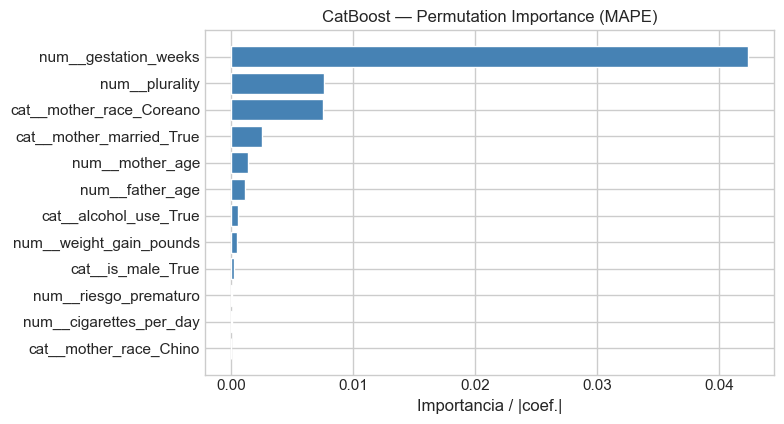

In [81]:
from sklearn.inspection import permutation_importance

resultado_importancia = permutation_importance(
    rand_search_cat.best_estimator_,
    X_test_r,
    y_test_r,
    n_repeats=10,
    random_state=RNG,
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=1
)

plot_top_importance(
    fn,
    resultado_importancia.importances_mean,
    f"{name} — Permutation Importance (MAPE)",
    top=20
)
plt.tight_layout()
plt.show()


REPORTE DE EVALUACIÓN CLÍNICA Y DE NEGOCIO
MAPE Global:           11.35%
Banda de Tolerancia:   4.88 lbs a 6.12 lbs
--------------------------------------------------
            Rango_Peso Volumen_Muestras MAE_Promedio MAPE_Promedio Tasa_Acierto_10pct %_del_Dataset
    < 3.5 lbs (Severo)              836     0.95 lbs        40.14%              21.5%          1.4%
  3.5 - 5.5 lbs (Bajo)            3,789     0.97 lbs        20.37%              34.8%          6.3%
5.5 - 7.5 lbs (Normal)           30,029     0.61 lbs         9.40%              62.3%         50.0%
  7.5 - 9.5 lbs (Alto)           24,005     0.89 lbs        10.61%              52.6%         40.0%
> 9.5 lbs (Macrosomía)            1,341     2.51 lbs        24.91%               0.0%          2.2%



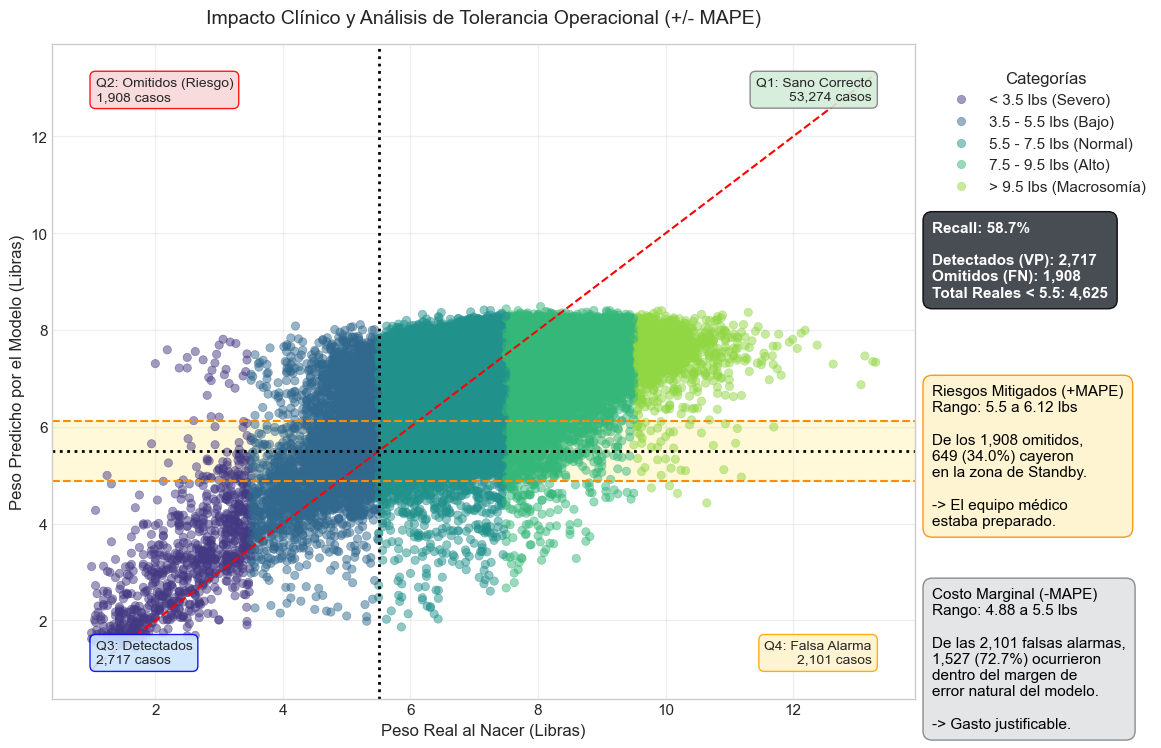

In [82]:
tabla_resultados_test = evaluar_modelo_peso(
    modelo = rand_search_cat.best_estimator_,
    X = X_test_r,
    y_true = y_test_r
)

In [83]:
joblib.dump(rand_search_cat.best_estimator_, "catboost_model.pkl")
print("Modelo guardado en: catboost_model.pkl")
print(f"Mejores hiperparametros: {rand_search_cat.best_params_}")

Modelo guardado en: catboost_model.pkl
Mejores hiperparametros: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 3, 'model__iterations': 200, 'model__depth': 8, 'model__bagging_temperature': 0.0}


### 5.7 Modelo 6 — Linear SVR

Máquinas de vectores de soporte en su variante lineal para regresión. Minimiza una función de pérdida ε-insensible con regularización L2, lo que la hace robusta ante outliers moderados. Al ser un modelo lineal, escala bien a grandes volúmenes de datos y sus coeficientes son directamente interpretables. La búsqueda de hiperparámetros se realiza sobre un subconjunto del conjunto de entrenamiento para reducir el tiempo de cómputo; el modelo final se reentrena sobre la totalidad de los datos con los mejores parámetros encontrados.

**Espacio de búsqueda:**
- `C` ∈ {0.0001, 0.001, 0.01, 0.1}
- `epsilon` ∈ {0.0, 0.01, 0.05, 0.1}
- `max_iter` = 5000 (iteraciones máximas del solver)
- `n_iter` = 20, `cv` = 4, `scoring` = neg_root_mean_squared_error


In [84]:
name = "LinearSVR"

pipe_base_svr = Pipeline([
    ("prep",  clone(prep_lin_r)),
    ("model", LinearSVR(random_state=RNG)), 
])

param_dist_svr = {
    "model__C":        [0.0001, 0.001, 0.01, 0.1],
    "model__epsilon":  [0.0, 0.01, 0.05, 0.1],
    "model__max_iter": [5000],
}

# Subsamplear para la busqueda de HPs: los optimos son estables con 200K filas
_SEARCH_N = N_SAMPLE_REG
_idx = np.random.default_rng(RNG).choice(len(X_train_r), size=min(_SEARCH_N, len(X_train_r)), replace=False)
X_search = X_train_r.iloc[_idx] if hasattr(X_train_r, "iloc") else X_train_r[_idx]
y_search = y_train_r.iloc[_idx] if hasattr(y_train_r, "iloc") else y_train_r[_idx]
w_search = weights[_idx] if weights is not None else None
print(f"Busqueda de HPs en {len(X_search):,} filas (de {len(X_train_r):,} totales)")

rand_search_svr = RandomizedSearchCV(
    pipe_base_svr,
    param_distributions=param_dist_svr,
    n_iter=20,
    cv=4,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
    random_state=RNG,
    return_train_score=True,
)

rand_search_svr.fit(X_search, y_search, model__sample_weight=w_search)

# Reentrenar el modelo final con los mejores HPs sobre TODOS los datos
best_params_svr = rand_search_svr.best_params_
pipe_final_svr = clone(pipe_base_svr)
pipe_final_svr.set_params(**best_params_svr)
pipe_final_svr.fit(X_train_r, y_train_r, model__sample_weight=weights)

# Sobreescribir best_estimator_ para que el resto del codigo lo use igual
rand_search_svr.best_estimator_ = pipe_final_svr

Busqueda de HPs en 279,999 filas (de 279,999 totales)
Fitting 4 folds for each of 16 candidates, totalling 64 fits


In [85]:
print("=" * 60)
print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
for param, value in rand_search_svr.best_params_.items():
    print(f"  {param.replace('model__', ''):<20s}: {value}")
print("=" * 60)

pipe = rand_search_svr.best_estimator_

for part, Xp, yp in [
    ("train", X_train_r, y_train_r),
    ("test",  X_test_r,  y_test_r),
]:
    pred = pipe.predict(Xp)
    m = regression_scores(yp, pred)
    m.update({"modelo": name, "particion": part})
    results_reg.append(m)

print("Resultados del modelo:")
print(pd.DataFrame(results_reg).query("modelo == @name"))

MEJORES HIPERPARÁMETROS ENCONTRADOS:
  max_iter            : 5000
  epsilon             : 0.0
  C                   : 0.1
Resultados del modelo:
    MAPE_%  dentro_10%     modelo particion
10 11.8100     53.5500  LinearSVR     train
11 11.8500     53.2300  LinearSVR      test


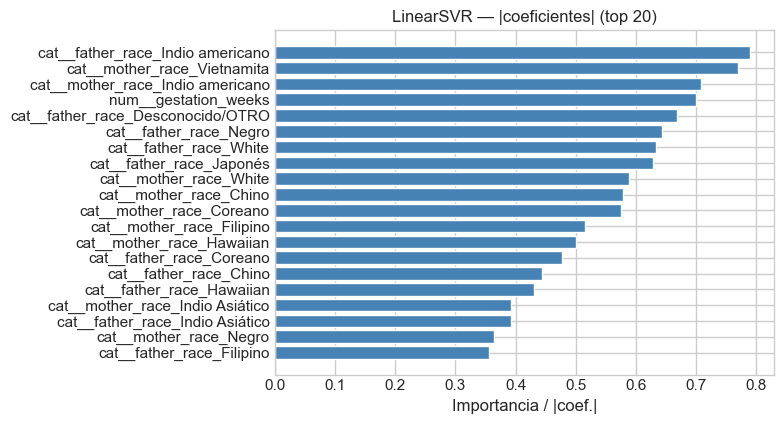

In [86]:
coef = np.abs(pipe.named_steps["model"].coef_.ravel())
fn   = get_feature_names_safe(pipe, Xr.columns)
plot_top_importance(fn[: len(coef)], coef, f"{name} — |coeficientes| (top 20)", top=20)
plt.tight_layout()
plt.show()


REPORTE DE EVALUACIÓN CLÍNICA Y DE NEGOCIO
MAPE Global:           11.85%
Banda de Tolerancia:   4.85 lbs a 6.15 lbs
--------------------------------------------------
            Rango_Peso Volumen_Muestras MAE_Promedio MAPE_Promedio Tasa_Acierto_10pct %_del_Dataset
    < 3.5 lbs (Severo)              836     1.01 lbs        43.45%              17.2%          1.4%
  3.5 - 5.5 lbs (Bajo)            3,789     1.04 lbs        21.71%              32.4%          6.3%
5.5 - 7.5 lbs (Normal)           30,029     0.64 lbs         9.85%              61.5%         50.0%
  7.5 - 9.5 lbs (Alto)           24,005     0.92 lbs        10.97%              50.3%         40.0%
> 9.5 lbs (Macrosomía)            1,341     2.50 lbs        24.82%               0.9%          2.2%



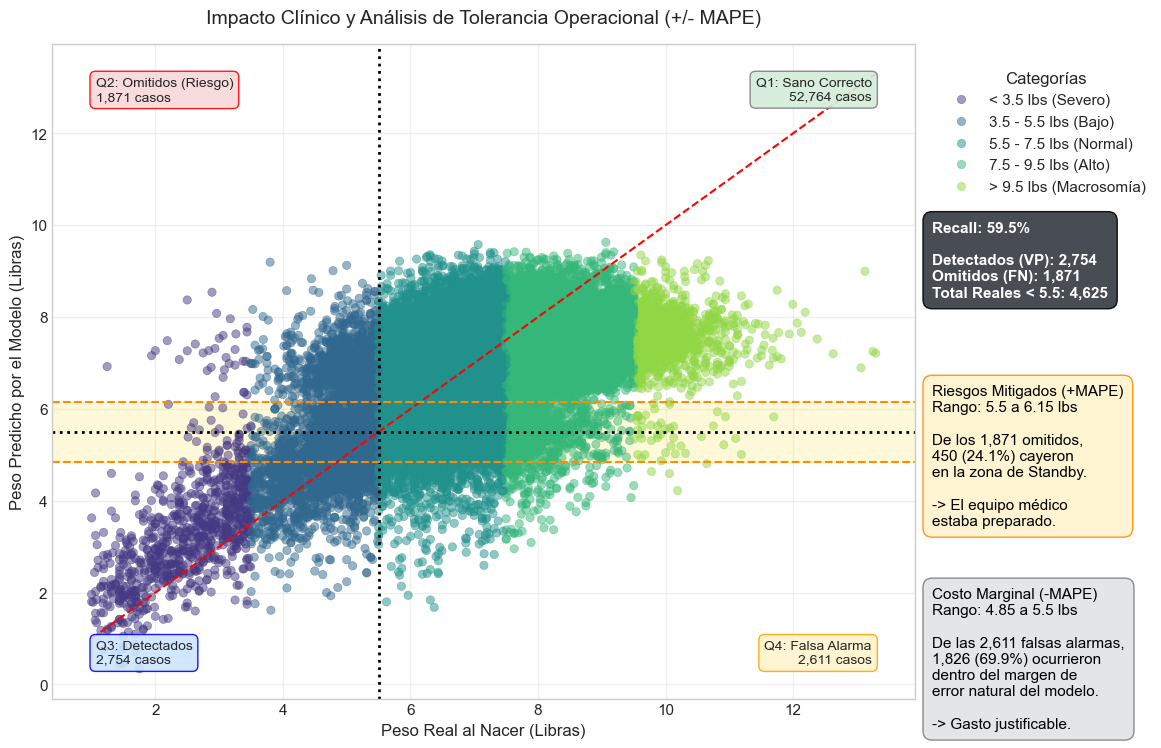

In [87]:
tabla_resultados_test = evaluar_modelo_peso(
    modelo = rand_search_svr.best_estimator_,
    X = X_test_r,
    y_true = y_test_r
)

In [88]:
import joblib
joblib.dump(rand_search_svr.best_estimator_, "linearsvr_model.pkl")
print("Modelo guardado en: linearsvr_model.pkl")
print(f"Mejores hiperparametros: {rand_search_svr.best_params_}")

Modelo guardado en: linearsvr_model.pkl
Mejores hiperparametros: {'model__max_iter': 5000, 'model__epsilon': 0.0, 'model__C': 0.1}


### 5.8 Modelo 7 — Red Neuronal (PyTorch)

Red neuronal *feedforward* (MLP) con arquitectura y hiperparámetros variables, entrenada con el optimizador Adam, *batch normalization* y *dropout* por capa para regularización. Se usa una pérdida MAPE como función de entrenamiento para alinear el objetivo del modelo con la métrica de evaluación, junto con *early stopping* sobre el % de predicciones dentro de ±10 % en validación. La búsqueda de hiperparámetros se realiza mediante *random search* con un presupuesto reducido de épocas (fase de búsqueda), seguida de un reentrenamiento completo con la mejor configuración encontrada (fase final).

**Búsqueda aleatoria de hiperparámetros**:

| Hiperparámetro | Espacio de búsqueda |
|---|---|
| `num_layers` | 1, 2, 3 |
| `dense_units_{i}` | 32, 64, 96, 128 (step=32) |
| `dropout_rate` | 0.1, 0.2, 0.3, 0.4, 0.5 (step=0.1) |
| `learning_rate` | log-uniforme [1e-4, 1e-2] |
| `activation` | relu, elu, leaky_relu, selu |

- **Fase de búsqueda:** 10 trials × 40 épocas máx. (patience=8 en validación).
- **Fase final:** mejor configuración reentrenada hasta 200 épocas (patience=30 en validación).
- **GPU:** se usa automáticamente si `torch.cuda.is_available()` es `True`.


In [89]:
import torch
import torch.nn as nn
import random
import copy
from torch.utils.data import DataLoader, TensorDataset

name   = "Red Neuronal"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# Preprocesamiento con el pipeline lineal (impute + escalar + OHE)
prep_nn    = clone(prep_lin_r)
X_train_nn = prep_nn.fit_transform(X_train_r)
X_val_nn   = prep_nn.transform(X_val_r)
X_test_nn  = prep_nn.transform(X_test_r)

# Convertir a densa si es necesario
def _arr(X):
    return X.toarray() if hasattr(X, "toarray") else X

X_train_nn = _arr(X_train_nn)
X_val_nn   = _arr(X_val_nn)
X_test_nn  = _arr(X_test_nn)

X_train_t = torch.tensor(X_train_nn, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_r.values, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t   = torch.tensor(X_val_nn,   dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_nn,  dtype=torch.float32).to(device)

input_dim = X_train_nn.shape[1]
print(f"Dimensión de entrada: {input_dim}")

Dispositivo: cuda
Dimensión de entrada: 32


In [90]:
# Funciones auxiliares
def mape_loss(y_pred, y_true):
    mask = y_true.abs() > 0.1
    return (((y_pred[mask] - y_true[mask]) / y_true[mask]).abs()).mean()

def pct_within_10(pred_np, true_np):
    return float(np.mean(
        np.abs((pred_np - true_np) / np.where(true_np == 0, 1, true_np)) <= 0.10
    ) * 100)

_ACTIVATIONS = {
    "relu":       nn.ReLU(),
    "elu":        nn.ELU(),
    "leaky_relu": nn.LeakyReLU(0.1),
    "selu":       nn.SELU(),
}

# Arquitectura flexible
class WeightNet(nn.Module):
    def __init__(self, input_dim, num_layers, dense_units, dropout_rate, activation="relu"):
        super().__init__()
        layers, prev = [], input_dim
        act_cls = {
            "relu":       nn.ReLU,
            "elu":        nn.ELU,
            "leaky_relu": lambda: nn.LeakyReLU(0.1),
            "selu":       nn.SELU,
        }[activation]
        for i in range(num_layers):
            layers += [
                nn.Linear(prev, dense_units[i]),
                nn.BatchNorm1d(dense_units[i]),
                act_cls(),
                nn.Dropout(dropout_rate),
            ]
            prev = dense_units[i]
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Espacio de hiperparametros (identico a 02_redes_hiperparametro.ipynb + activacion)
HP_NUM_LAYERS    = [1, 2, 3]                        # hp.Int(num_layers, 1, 3)
HP_DENSE_UNITS   = [32, 64, 96, 128]                # hp.Int(fdense_units_{i}, 32, 128, step=32)
HP_DROPOUT_RATES = [0.1, 0.2, 0.3, 0.4, 0.5]       # hp.Float(dropout_rate, 0.1, 0.5, step=0.1)
HP_LR_RANGE      = (1e-4, 1e-2)                     # hp.Float(learning_rate, 1e-4, 1e-2, sampling=log)
HP_ACTIVATIONS   = ["relu", "elu", "leaky_relu", "selu"]

In [91]:
N_TRIALS        = 10
EPOCHS_SEARCH   = 40
PATIENCE_SEARCH = 8

random.seed(RNG); np.random.seed(RNG)
print(f"Busqueda aleatoria — {N_TRIALS} trials x {EPOCHS_SEARCH} epocas max.")

best_trial_score = float("inf")  # MAPE: menor es mejor
best_hp          = None

for trial in range(N_TRIALS):
    num_layers   = random.choice(HP_NUM_LAYERS)
    dropout_rate = random.choice(HP_DROPOUT_RATES)
    activation   = random.choice(HP_ACTIVATIONS)
    lr           = float(np.exp(np.random.uniform(np.log(HP_LR_RANGE[0]), np.log(HP_LR_RANGE[1]))))
    hp = {
        "num_layers":    num_layers,
        "dropout_rate":  dropout_rate,
        "activation":    activation,
        "learning_rate": lr,
        **{f"dense_units_{i}": random.choice(HP_DENSE_UNITS) for i in range(num_layers)},
    }
    dense_units = [hp[f"dense_units_{i}"] for i in range(num_layers)]

    m_t = WeightNet(input_dim, num_layers, dense_units, dropout_rate, activation).to(device)
    opt = torch.optim.Adam(m_t.parameters(), lr=lr, weight_decay=1e-5)
    ldr = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=2048, shuffle=True)

    best_val, no_imp = float("inf"), 0
    for _ in range(EPOCHS_SEARCH):
        m_t.train()
        for xb, yb in ldr:
            opt.zero_grad(); mape_loss(m_t(xb), yb).backward(); opt.step()
        m_t.eval()
        with torch.no_grad():
            vp = m_t(X_val_t).cpu().numpy().ravel()
        vy = y_val_r.values; mask = vy != 0
        val_mape = float(np.mean(np.abs((vp[mask] - vy[mask]) / vy[mask])) * 100)
        if val_mape < best_val: best_val, no_imp = val_mape, 0
        else:                   no_imp += 1
        if no_imp >= PATIENCE_SEARCH: break

    print(f"  Trial {trial+1:2d}/{N_TRIALS} | layers={num_layers}, units={dense_units}, "
          f"dropout={dropout_rate}, act={activation}, lr={lr:.5f} | val MAPE={best_val:.2f}%")
    if best_val < best_trial_score:
        best_trial_score, best_hp = best_val, hp

print("=" * 60)
print("MEJORES HIPERPARAMETROS ENCONTRADOS:")
for k, v in best_hp.items():
    print(f"  {k:<20s}: {v}")
print("=" * 60)
print(f"Mejor val MAPE: {best_trial_score:.2f}%")

Busqueda aleatoria — 10 trials x 40 epocas max.
  Trial  1/10 | layers=3, units=[96, 64, 64], dropout=0.1, act=relu, lr=0.00056 | val MAPE=11.14%
  Trial  2/10 | layers=1, units=[128], dropout=0.1, act=relu, lr=0.00797 | val MAPE=11.19%
  Trial  3/10 | layers=1, units=[64], dropout=0.1, act=relu, lr=0.00291 | val MAPE=11.23%
  Trial  4/10 | layers=1, units=[64], dropout=0.5, act=relu, lr=0.00158 | val MAPE=11.37%
  Trial  5/10 | layers=3, units=[64, 128, 96], dropout=0.5, act=selu, lr=0.00021 | val MAPE=11.49%
  Trial  6/10 | layers=1, units=[96], dropout=0.2, act=selu, lr=0.00021 | val MAPE=11.26%
  Trial  7/10 | layers=2, units=[96, 32], dropout=0.2, act=elu, lr=0.00013 | val MAPE=11.33%
  Trial  8/10 | layers=1, units=[96], dropout=0.4, act=relu, lr=0.00540 | val MAPE=11.37%
  Trial  9/10 | layers=2, units=[32, 128], dropout=0.5, act=leaky_relu, lr=0.00159 | val MAPE=11.36%
  Trial 10/10 | layers=3, units=[32, 96, 96], dropout=0.1, act=selu, lr=0.00261 | val MAPE=11.16%
MEJORES HIPE

In [92]:
EPOCHS_FINAL   = 200
PATIENCE_FINAL = 30

num_layers_f  = best_hp["num_layers"]
dense_units_f = [best_hp[f"dense_units_{i}"] for i in range(num_layers_f)]

model_nn  = WeightNet(input_dim, num_layers_f, dense_units_f,
                      best_hp["dropout_rate"], best_hp["activation"]).to(device)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=best_hp["learning_rate"], weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=2048, shuffle=True)

best_val_mape, best_state, epochs_no_improve = float("inf"), None, 0

for epoch in range(EPOCHS_FINAL):
    model_nn.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = mape_loss(model_nn(xb), yb)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    scheduler.step(epoch_loss / len(train_loader))

    model_nn.eval()
    with torch.no_grad():
        val_pred = model_nn(X_val_t).cpu().numpy().ravel()
    vy = y_val_r.values; mask = vy != 0
    val_mape = float(np.mean(np.abs((val_pred[mask] - vy[mask]) / vy[mask])) * 100)

    if val_mape < best_val_mape:
        best_val_mape, best_state, epochs_no_improve = val_mape, copy.deepcopy(model_nn.state_dict()), 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS_FINAL} — val MAPE: {val_mape:.2f}%")
    if epochs_no_improve >= PATIENCE_FINAL:
        print(f"Early stopping en epoch {epoch+1}")
        break

model_nn.load_state_dict(best_state)
print(f"Mejor val MAPE: {best_val_mape:.2f}%")

Epoch 20/200 — val MAPE: 11.17%
Epoch 40/200 — val MAPE: 11.14%
Epoch 60/200 — val MAPE: 11.16%
Epoch 80/200 — val MAPE: 11.14%
Early stopping en epoch 95
Mejor val MAPE: 11.13%


In [95]:
model_nn.eval()
with torch.no_grad():
    pred_train = model_nn(X_train_t).cpu().numpy().ravel()
    pred_test  = model_nn(X_test_t).cpu().numpy().ravel()

for part, y_arr, pred_arr in [
    ("train", y_train_r.values, pred_train),
    ("test",  y_test_r.values,  pred_test),
]:
    m = regression_scores(y_arr, pred_arr)
    m.update({"modelo": "Red Neuronal", "particion": part})
    results_reg.append(m)

print("Resultados del modelo:")
print(pd.DataFrame(results_reg).query('modelo == "Red Neuronal"'))



Resultados del modelo:
    MAPE_%  dentro_10%        modelo particion
12 11.0800     56.2900  Red Neuronal     train
13 11.1600     56.0100  Red Neuronal      test



REPORTE DE EVALUACIÓN CLÍNICA Y DE NEGOCIO
MAPE Global:           11.16%
Banda de Tolerancia:   4.89 lbs a 6.11 lbs
--------------------------------------------------
            Rango_Peso Volumen_Muestras MAE_Promedio MAPE_Promedio Tasa_Acierto_10pct %_del_Dataset
    < 3.5 lbs (Severo)              836     0.89 lbs        35.75%              27.5%          1.4%
  3.5 - 5.5 lbs (Bajo)            3,789     1.16 lbs        24.39%              23.4%          6.3%
5.5 - 7.5 lbs (Normal)           30,029     0.57 lbs         8.83%              66.0%         50.0%
  7.5 - 9.5 lbs (Alto)           24,005     0.87 lbs        10.34%              52.8%         40.0%
> 9.5 lbs (Macrosomía)            1,341     2.54 lbs        25.17%               0.0%          2.2%



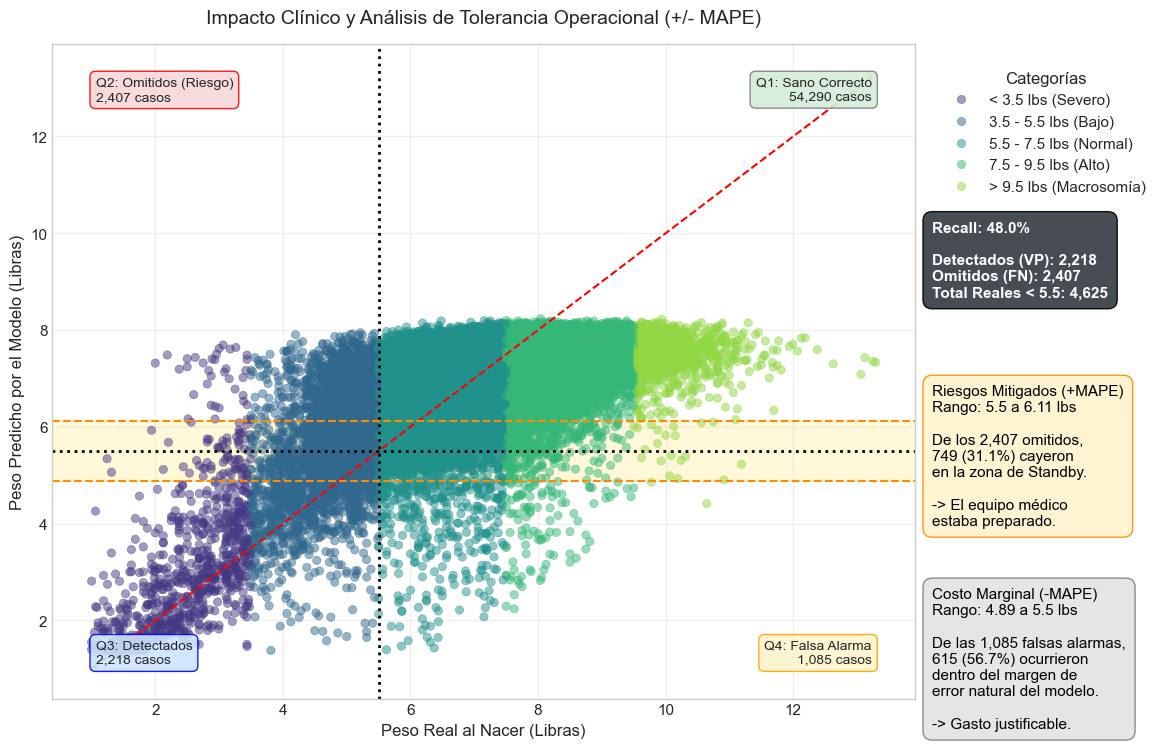

In [96]:
# Wrapper sklearn-compatible para poder llamar evaluar_modelo_peso
class _NNWrapper:
    def predict(self, X):
        Xp = prep_nn.transform(X)
        if hasattr(Xp, "toarray"): Xp = Xp.toarray()
        t = torch.tensor(Xp, dtype=torch.float32).to(device)
        model_nn.eval()
        with torch.no_grad():
            return model_nn(t).cpu().numpy().ravel()

tabla_resultados_test = evaluar_modelo_peso(
    modelo = _NNWrapper(),
    X = X_test_r,
    y_true = y_test_r
)

In [97]:
import joblib
model_nn.cpu()
joblib.dump({"model": model_nn, "preprocessor": prep_nn, "best_hp": best_hp}, "nn_model.pkl")
print("Modelo guardado en: nn_model.pkl")
model_nn.to(device)

Modelo guardado en: nn_model.pkl


WeightNet(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=96, bias=True)
    (1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=96, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

#### Importancia de variables — Permutation Importance (MAPE)

Se calcula la importancia por permutación sobre el conjunto de test: para cada variable se baraja aleatoriamente su columna 10 veces y se mide cuánto empeora el MAPE del modelo. Una caída mayor en MAPE indica mayor relevancia de la variable.

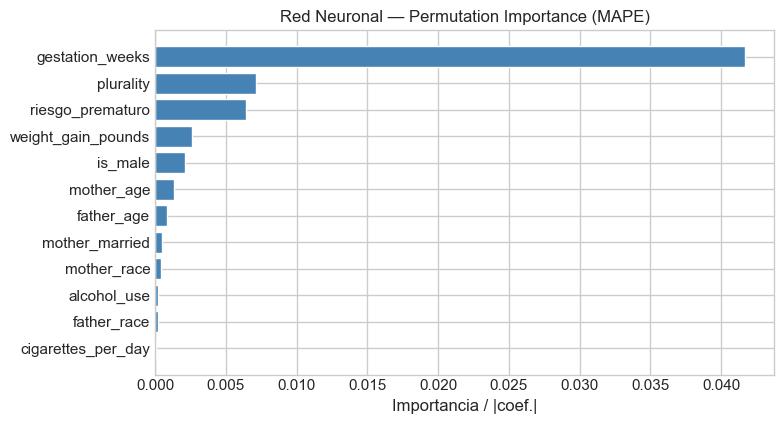


Resultados del modelo:
    MAPE_%  dentro_10%        modelo particion
12 11.0800     56.2900  Red Neuronal     train
13 11.1600     56.0100  Red Neuronal      test


In [98]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

class _NNSklearnWrapper(BaseEstimator, RegressorMixin):
    """Wrapper sklearn-compatible para permutation_importance."""
    def fit(self, X, y=None): return self
    def predict(self, X):
        Xp = prep_nn.transform(X)
        if hasattr(Xp, "toarray"): Xp = Xp.toarray()
        t = torch.tensor(np.array(Xp, dtype=np.float32)).to(device)
        model_nn.eval()
        with torch.no_grad():
            return model_nn(t).cpu().numpy().ravel()

fn_nn = list(X_test_r.columns)

resultado_importancia_nn = permutation_importance(
    _NNSklearnWrapper(),
    X_test_r,
    y_test_r,
    n_repeats=10,
    random_state=RNG,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=1
)

plot_top_importance(
    fn_nn,
    resultado_importancia_nn.importances_mean,
    "Red Neuronal — Permutation Importance (MAPE)",
    top=20
)
plt.tight_layout()
plt.show()

print("\nResultados del modelo:")
print(pd.DataFrame(results_reg).query("modelo == 'Red Neuronal'"))

## 6. Resultados comparativos

Se comparan los siete modelos entrenados en las particiones de **train** y **test** usando dos métricas complementarias:

- **MAPE (%)**: Error porcentual absoluto medio; mide la magnitud promedio del error relativo al valor real. Menor es mejor.
- **Dentro 10 %**: Porcentaje de predicciones cuya desviación respecto al peso real es ≤ 10 %. Mayor es mejor.

La tabla siguiente muestra los resultados en test para cada modelo, ordenados de mejor a peor MAPE. 

In [99]:
# Tabla comparativa de todos los modelos en test
df_results = pd.DataFrame(results_reg)

# Pivot: una fila por modelo, columnas train/test para cada metrica
pivot = df_results.pivot_table(
    index='modelo',
    columns='particion',
    values=['MAPE_%', 'dentro_10%'],
    aggfunc='first'
)
pivot.columns = [f'{m}_{p}' for m, p in pivot.columns]
pivot = pivot.reset_index()

# Ordenar por MAPE en test (menor es mejor)
if 'MAPE_%_test' in pivot.columns:
    pivot = pivot.sort_values('MAPE_%_test').reset_index(drop=True)

print('\n=== Resultados comparativos (test) ===')
display(pivot)



=== Resultados comparativos (test) ===


,modelo,MAPE_%_test,MAPE_%_train,dentro_10%_test,dentro_10%_train
0,Red Neuronal,11.1600,11.0800,56.0100,56.2900
1,CatBoost,11.3500,11.2700,54.7300,55.1000
2,XGBRegressor,11.4000,10.9500,54.6200,55.9900
3,Random Forest,11.5200,10.6700,54.9800,57.3400
4,Regresión con regularización,11.8400,11.8000,53.1700,53.5100
5,LinearSVR,11.8500,11.8100,53.2300,53.5500
6,LinearRegression,12.1300,12.0900,55.2400,55.5800


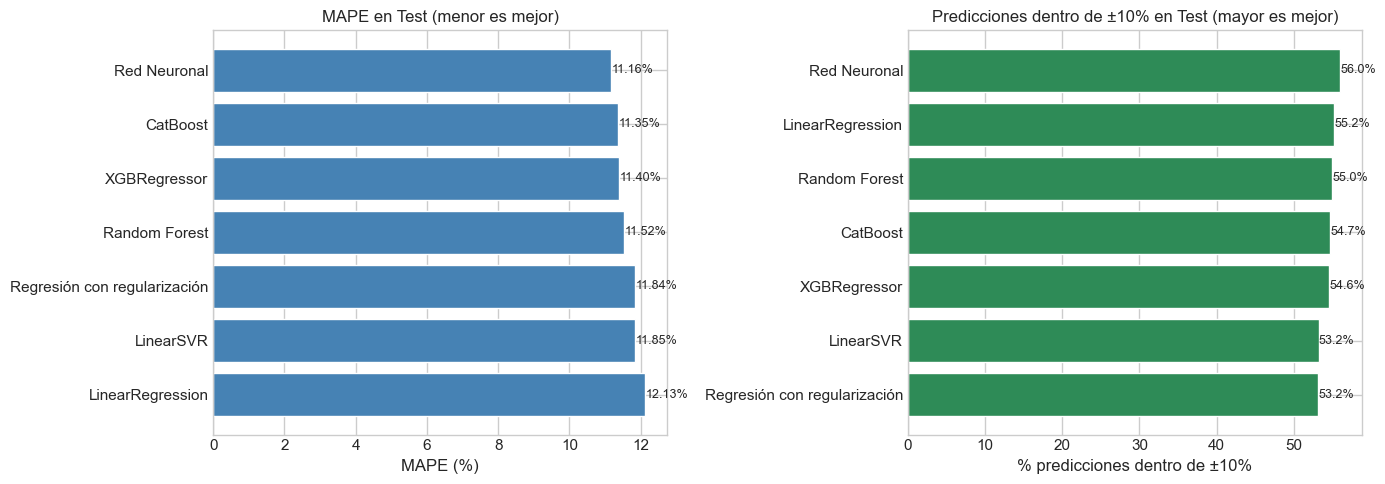

In [100]:
# Visualizacion comparativa: MAPE y Dentro_10% en test
df_test = df_results[df_results["particion"] == "test"].copy()
df_test = df_test.drop_duplicates(subset="modelo", keep="first")
df_test = df_test.sort_values("MAPE_%").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAPE (menor es mejor)
bars1 = axes[0].barh(df_test["modelo"], df_test["MAPE_%"], color="steelblue")
axes[0].set_xlabel("MAPE (%)")
axes[0].set_title("MAPE en Test (menor es mejor)")
axes[0].invert_yaxis()
for bar, val in zip(bars1, df_test["MAPE_%"]):
    axes[0].text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                 f"{val:.2f}%", va="center", fontsize=9)

# Dentro_10% (mayor es mejor)
df_test_sorted = df_test.sort_values("dentro_10%", ascending=False).reset_index(drop=True)
bars2 = axes[1].barh(df_test_sorted["modelo"], df_test_sorted["dentro_10%"], color="seagreen")
axes[1].set_xlabel("% predicciones dentro de ±10%")
axes[1].set_title("Predicciones dentro de ±10% en Test (mayor es mejor)")
axes[1].invert_yaxis()
for bar, val in zip(bars2, df_test_sorted["dentro_10%"]):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


### 6.1 Análisis de resultados
